<a href="https://colab.research.google.com/github/gforconi/UTNIA2025/blob/main/CNN_2026/Clasificador_Frutas_UTN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍎 Clasificación de Frutas con Redes Neuronales Convolucionales
## Universidad Tecnológica Nacional – Regional Rosario
### Materia: Inteligencia Artificial | PyTorch 2.x

---

## Objetivos
1. Preparar y explorar un dataset de imágenes de frutas
2. Diseñar una CNN desde cero con PyTorch
3. Entrenar, evaluar y visualizar predicciones
4. Comparar resultados entre un dataset controlado y uno realista

## Estrategia: dos datasets, dos mundos

| Etapa | Dataset | Objetivo pedagógico |
|-------|---------|---------------------|
| **Etapa 1** | UTN-IA 2026 · Estudio Visual - Etapa 1 | Introducir CNNs, obtener ~95% accuracy rápido |
| **Etapa 2** | UTN-IA 2026 · Food Classification - Training Set | Generalización, overfitting, data augmentation |

> **Pregunta disparadora:** ¿Por qué la misma arquitectura puede obtener 95% en un dataset y solo 70% en otro?


## Celda 0: Configuración del entorno

In [1]:
import torch

# Verificar disponibilidad de GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No se detectó GPU. En Colab: Entorno de ejecución → Cambiar tipo → GPU T4')


Dispositivo: cuda
GPU: Tesla T4
Memoria: 15.6 GB


In [2]:
# Instalar dependencias adicionales
#!pip install -q kaggle scikit-learn seaborn

import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Semilla para reproducibilidad
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

print(f'PyTorch {torch.__version__} | Torchvision {torchvision.__version__}')
print('✅ Librerías importadas')


PyTorch 2.10.0+cu128 | Torchvision 0.25.0+cu128
✅ Librerías importadas


In [3]:
'''
ruta = Path("/kaggle/temp")

print("Subcarpetas directas:")
for elemento in ruta.iterdir():
    if elemento.is_dir():
        print(elemento.name)
'''

'\nruta = Path("/kaggle/temp")\n\nprint("Subcarpetas directas:")\nfor elemento in ruta.iterdir():\n    if elemento.is_dir():\n        print(elemento.name)\n'

---
# 🍊 ETAPA 1: UTN-IA 2026 · Estudio Visual - Etapa 1
## Dataset controlado para aprender los fundamentos

**UTN-IA 2026 · Estudio Visual - Etapa 1** tiene imágenes sobre fondo blanco uniforme. Ideal para introducir CNN porque:
- Las imágenes son muy distintas entre clases → fácil de clasificar
- El modelo alcanza ~95% rápidamente → resultados exitosos en clase
- Permite enfocarse en la arquitectura, no en el preprocesamiento

**Link Kaggle:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-estudio-visual-etapa-1  
**Licencia:** Apache 2.0


### Paso 1.1: Descarga del dataset

Para descargar desde Kaggle necesitás una API key:
1. Ir a kaggle.com → tu perfil → Settings → API → Create New Token
2. Copiar `API TOKEN`
3. Subirlo con la celda de abajo


In [4]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b983894342aafc292b626934d1c0e135"

In [5]:
# Descargar UTN-IA 2026 · Estudio Visual - Etapa 1 desde Kaggle
!kaggle datasets download -d geronimoforconi/utn-ia-2026-estudio-visual-etapa-1 -p /kaggle/input --unzip -q
print("✅ Dataset Estudio Visual - Etapa 1 descargado")


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-estudio-visual-etapa-1
License(s): CC-BY-NC-SA-4.0
[Errno 30] Read-only file system: '/kaggle/input/utn-ia-2026-estudio-visual-etapa-1.zip'
✅ Dataset Estudio Visual - Etapa 1 descargado


In [6]:
DATASET_RAIZ = '/kaggle/input/datasets/juancruzmondino/datos-necesarios/notebook_frutas_estudio/'
BASE_DIR = Path('/kaggle/input/datasets/juancruzmondino/datos-necesarios/notebook_frutas_estudio/')
CLASES_SELECCIONADAS = ['Apple Golden 1', 'Banana 1', 'Grape Blue 1', 'Strawberry 1', 'Cherry 1']


### Paso 1.2: Exploración visual del dataset

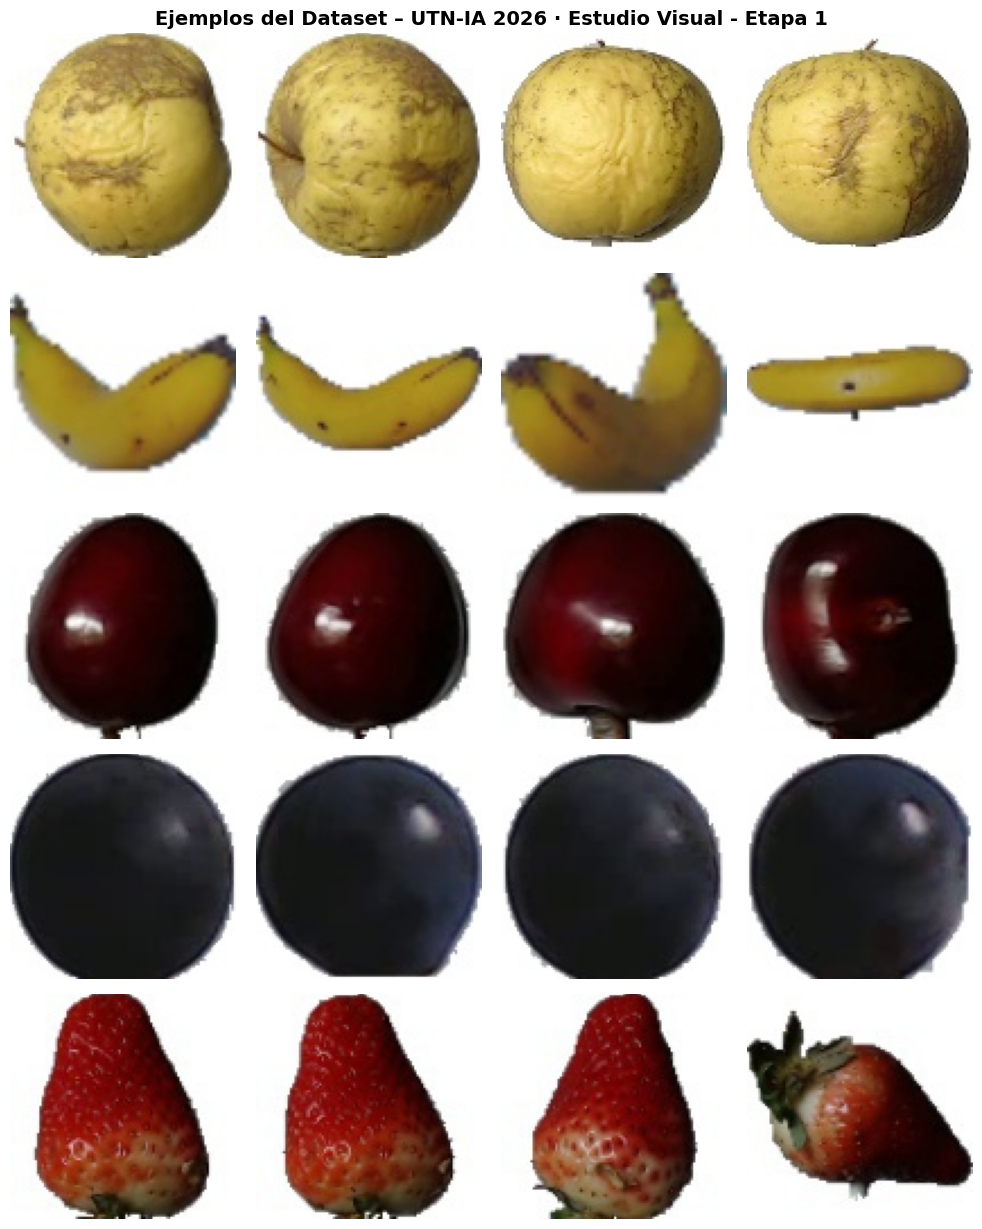

In [7]:
def mostrar_ejemplos(base_dir, split='train', n=4):
    clases = sorted(os.listdir(base_dir / split))
    fig, axes = plt.subplots(len(clases), n, figsize=(n*2.5, len(clases)*2.5))
    fig.suptitle('Ejemplos del Dataset – UTN-IA 2026 · Estudio Visual - Etapa 1', fontsize=14, fontweight='bold')
    for i, clase in enumerate(clases):
        imgs = list((base_dir / split / clase).glob('*.jpg'))[:n]
        for j, p in enumerate(imgs):
            axes[i][j].imshow(Image.open(p))
            axes[i][j].axis('off')
            if j == 0:
                axes[i][j].set_ylabel(clase.split()[0], fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

mostrar_ejemplos(BASE_DIR)


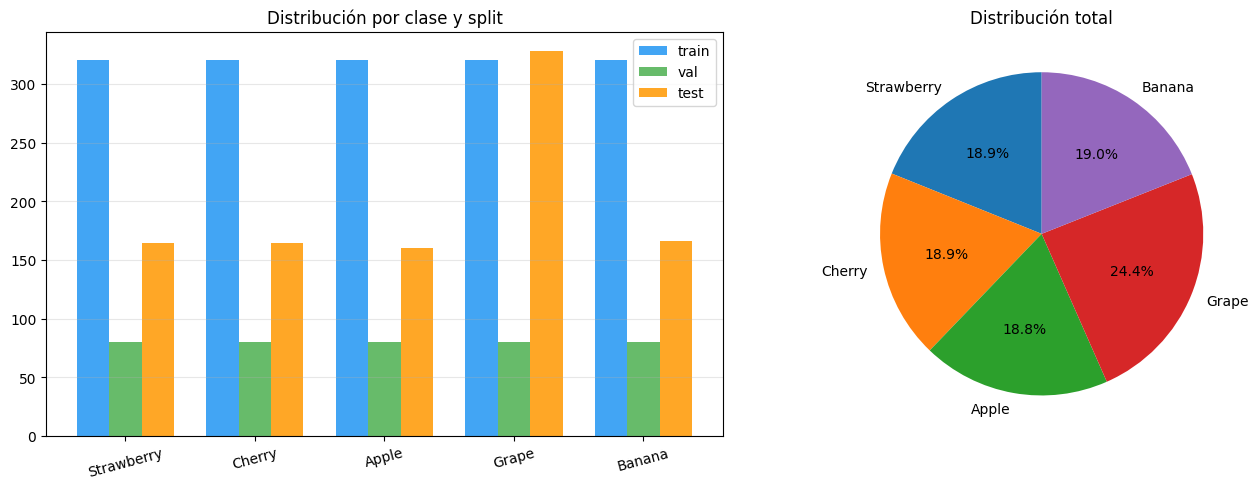

Clase                     Train      Val     Test
--------------------------------------------------
Strawberry 1                320       80      164
Cherry 1                    320       80      164
Apple Golden 1              320       80      160
Grape Blue 1                320       80      328
Banana 1                    320       80      166


In [8]:
def analizar_distribucion(base_dir):
    splits = ['train', 'val', 'test']
    conteos = {s: {} for s in splits}
    for s in splits:
        sd = base_dir / s
        if sd.exists():
            for c in os.listdir(sd):
                conteos[s][c] = len(list((sd/c).glob('*.jpg')))

    clases = list(conteos['train'].keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(clases)); w = 0.25
    for idx, (s, col) in enumerate(zip(splits, ['#2196F3','#4CAF50','#FF9800'])):
        ax1.bar(x + idx*w, [conteos[s].get(c,0) for c in clases], w, label=s, color=col, alpha=0.85)
    ax1.set_xticks(x+w); ax1.set_xticklabels([c.split()[0] for c in clases], rotation=15)
    ax1.set_title('Distribución por clase y split'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

    totales = {c: sum(conteos[s].get(c,0) for s in splits) for c in clases}
    ax2.pie(totales.values(), labels=[c.split()[0] for c in clases], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribución total')
    plt.tight_layout(); plt.show()

    print(f'{"Clase":<22} {"Train":>8} {"Val":>8} {"Test":>8}')
    print('-'*50)
    for c in clases:
        print(f'{c:<22} {conteos["train"].get(c,0):>8} {conteos["val"].get(c,0):>8} {conteos["test"].get(c,0):>8}')

analizar_distribucion(BASE_DIR)


### Paso 1.3: Preprocesamiento y Data Augmentation

Las CNNs esperan tensores normalizados. Definimos dos pipelines:
- **transform_base**: solo lo esencial (resize, tensor, normalize) → para val/test
- **transform_train**: agrega variaciones aleatorias → solo para entrenamiento

Los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` son los de ImageNet. Son los parámetros de normalización por canal RGB, calculados originalmente sobre el dataset ImageNet (1.2 millones de imágenes).

**Data Augmentation:**

Aplica solo al training set, nunca a val ni test. El objetivo es que en cada epoch el modelo vea versiones ligeramente distintas de la misma imagen, lo que actúa como regularización — el modelo no puede memorizar las imágenes de entrenamiento porque cada vez son un poco diferentes.
El efecto es equivalente a tener más datos sin recolectar nada nuevo.

In [9]:
IMG_SIZE   = 64
BATCH_SIZE = 32
NUM_CLASES = 5
# Ponemos estos valores para no calcularlos
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Pipeline base: val y test
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Pipeline con augmentation: solo training
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 8, IMG_SIZE + 8)),   # → 72×72
    transforms.RandomCrop(IMG_SIZE),                   # → recorta 64×64 al azar
    transforms.RandomHorizontalFlip(p=0.5),            # → espejo horizontal, 50% de chances
    transforms.RandomRotation(degrees=15),             # → rota entre -15° y +15°
    transforms.ColorJitter(brightness=0.3,             # → varía brillo
                          contrast=0.3,                # → varía contraste
                          saturation=0.2,              # → varía saturación
                          hue=0.1),                    # → varía tono de color
    transforms.ToTensor(),                             # → Convierte a tensor
    transforms.Normalize(mean=MEAN, std=STD)           # → Normaliza
])

print('✅ Transformaciones definidas')
print('   Train: resize+crop+flip+rotación+colorjitter+normalize')
print('   Val/Test: solo resize+normalize')


✅ Transformaciones definidas
   Train: resize+crop+flip+rotación+colorjitter+normalize
   Val/Test: solo resize+normalize


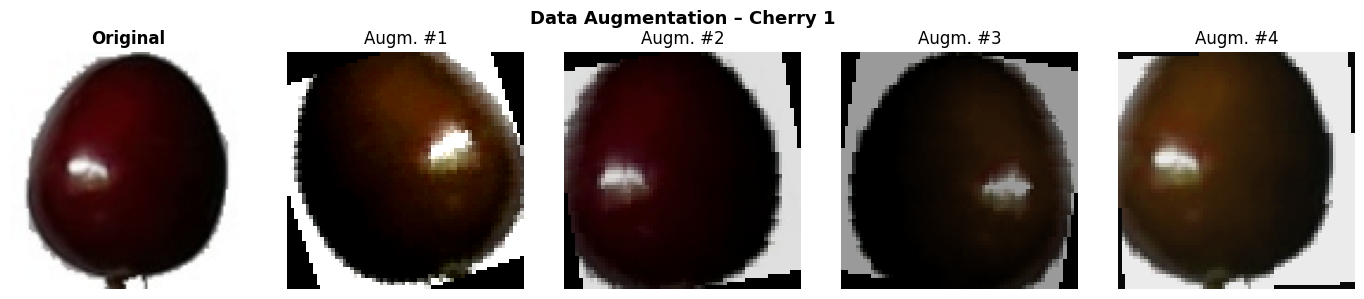

In [10]:
def visualizar_augmentation(base_dir, clase, n=4):
    """Muestra la misma imagen con distintas augmentaciones."""
    carpeta = base_dir / 'train' / clase
    img_orig = Image.open(list(carpeta.glob('*.jpg'))[0])
    aug = transforms.Compose([
        transforms.Resize((IMG_SIZE+8, IMG_SIZE+8)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(0.4, 0.4, 0.3, 0.1),
    ])
    fig, axes = plt.subplots(1, n+1, figsize=(14, 3))
    axes[0].imshow(img_orig); axes[0].set_title('Original', fontweight='bold'); axes[0].axis('off')
    for i in range(n):
        axes[i+1].imshow(aug(img_orig)); axes[i+1].set_title(f'Augm. #{i+1}'); axes[i+1].axis('off')
    plt.suptitle(f'Data Augmentation – {clase}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar_augmentation(BASE_DIR, CLASES_SELECCIONADAS[-1])


In [11]:
# Cargar datasets con ImageFolder (espera estructura: raiz/clase/imagen.jpg)
train_dataset = ImageFolder(str(BASE_DIR / 'train'), transform=transform_train)
val_dataset   = ImageFolder(str(BASE_DIR / 'val'),   transform=transform_base)
test_dataset  = ImageFolder(str(BASE_DIR / 'test'),  transform=transform_base)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

class_names = train_dataset.classes
print(f'✅ Datasets cargados: train={len(train_dataset)} | val={len(val_dataset)} | test={len(test_dataset)}')
print(f'   Clases: {class_names}')
imgs, labels = next(iter(train_loader))
print(f'   Forma del batch: {imgs.shape}  → [batch, canales, H, W]')


✅ Datasets cargados: train=1600 | val=400 | test=982
   Clases: ['Apple Golden 1', 'Banana 1', 'Cherry 1', 'Grape Blue 1', 'Strawberry 1']
   Forma del batch: torch.Size([32, 3, 64, 64])  → [batch, canales, H, W]


### Paso 1.4: Arquitectura de la CNN

```
Entrada (3×64×64)
    ↓ Conv1 (32 filtros 3×3) + BatchNorm + ReLU + MaxPool → 32×32×32
    ↓ Conv2 (64 filtros 3×3) + BatchNorm + ReLU + MaxPool → 64×16×16
    ↓ Conv3 (128 filtros 3×3) + BatchNorm + ReLU + MaxPool → 128×8×8
    ↓ Flatten → 8192
    ↓ Linear(8192, 256) + ReLU + Dropout(0.5)
    ↓ Linear(256, 5) → predicción
```

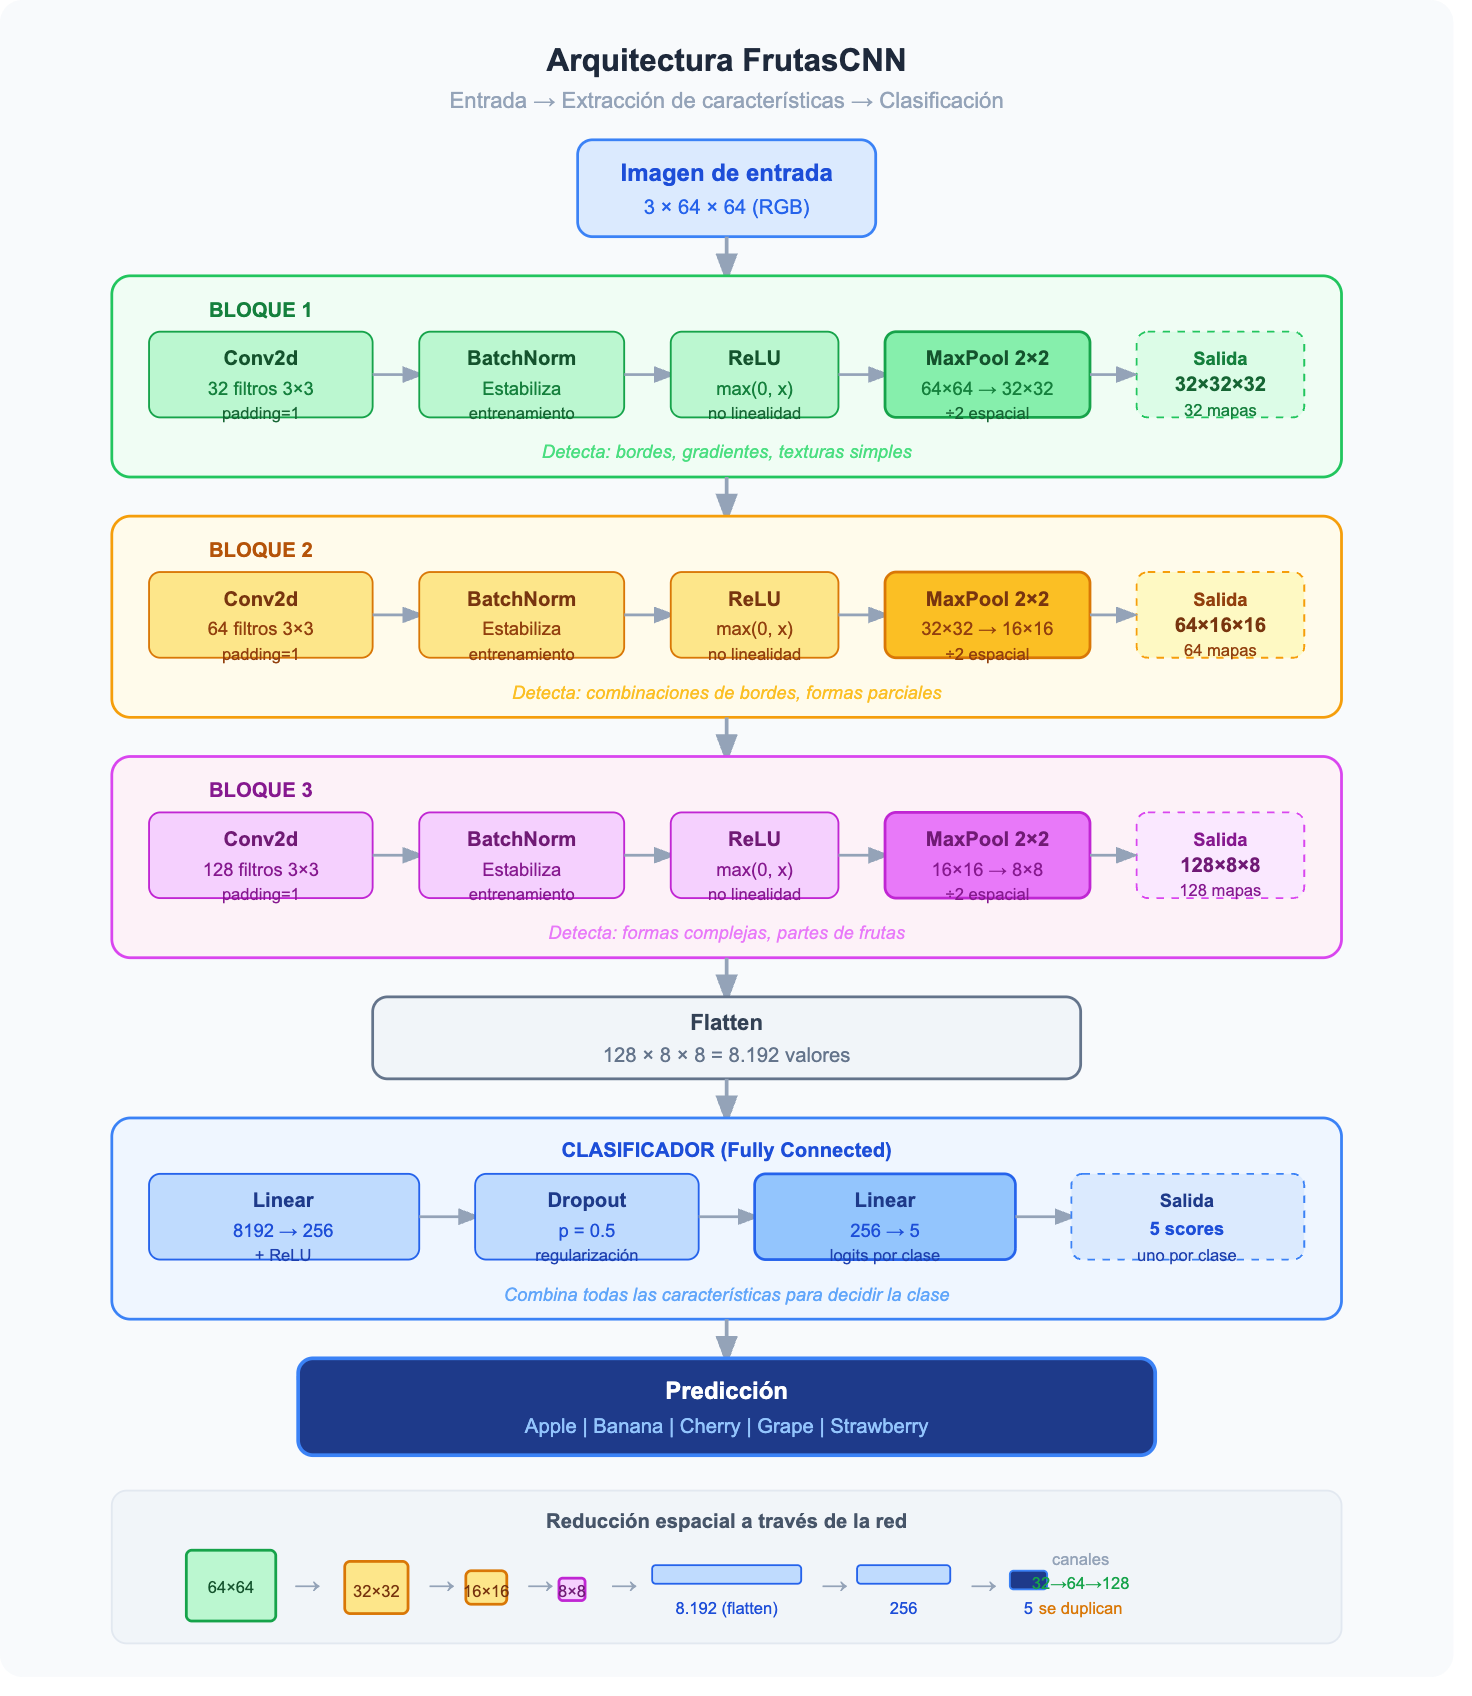


In [12]:
class FrutasCNN(nn.Module):
    """
    CNN para clasificación de frutas.
    Cada bloque duplica filtros (32->64->128) y reduce tamaño espacial con MaxPool.
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # Bloque 1: detecta bordes y texturas simples
        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 canales RGB -> 32 mapas
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 64x64 -> 32x32
        )
        # Bloque 2: detecta combinaciones de bordes
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32x32 -> 16x16
        )
        # Bloque 3: detecta representaciones complejas
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16x16 -> 8x8
        )
        # Clasificador final
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),   # Regularización contra overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        return self.clasificador(x)

modelo = FrutasCNN(num_classes=NUM_CLASES).to(device)
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'✅ Modelo creado | Parámetros entrenables: {total_params:,}')
print(modelo)


✅ Modelo creado | Parámetros entrenables: 2,192,389
FrutasCNN(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=

**Test rápido:**
Crea una imagen falsa y la pasa por el modelo para verificar que las dimensiones son correctas antes de entrenar con datos reales.

`torch.randn(4, 3, IMG_SIZE, IMG_SIZE)` genera números aleatorios con la misma forma que un batch real — 4 imágenes, 3 canales RGB, 64×64 píxeles. El contenido no importa, solo la forma.

Luego pasa ese tensor por el modelo y verifica que la salida tenga la forma correcta: [4, 5] — 4 imágenes, 5 scores (uno por fruta).

In [13]:
# Test rápido de dimensiones
with torch.no_grad():
    x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    y = modelo(x)
    print(f'✅ Test de dimensiones:')
    print(f'   Entrada:  {x.shape}')
    print(f'   Salida:   {y.shape}  → 1 score por clase')


✅ Test de dimensiones:
   Entrada:  torch.Size([4, 3, 64, 64])
   Salida:   torch.Size([4, 5])  → 1 score por clase


### Paso 1.5: Entrenamiento

El ciclo de entrenamiento por cada batch:
1. **Forward pass**: el modelo hace predicciones
2. **Loss**: medimos el error con CrossEntropyLoss
3. **Backward pass**: calculamos gradientes
4. **Update**: el optimizador ajusta los pesos


In [14]:
EPOCHS = 20
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

@torch.no_grad()
def evaluar(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correcto = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)

            loss = criterion(out, labels)

            _, preds = out.max(1)

            total_loss += loss.item() * imgs.size(0)
            correcto += preds.eq(labels).sum().item()
            total += imgs.size(0)

            # Guardar etiquetas reales y predicciones
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    loss = total_loss / total
    acc = correcto / total
    f1 = f1_score(y_true, y_pred, average='macro')

    return loss, acc, f1

# Bucle principal
historial = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}
mejor_val_loss = float('inf')
CKPT_PATH = '/kaggle/working/mejor_modelo.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10} | {"Val F1":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS + 1):
    tl, ta = entrenar_epoch(modelo, train_loader, criterion, optimizer, device)
    vl, va, vf1 = evaluar(modelo, val_loader, criterion, device)
    scheduler.step(vl)
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va),('val_f1',vf1)]:
        historial[k].append(v)
    marca = ''
    if vl < mejor_val_loss:
        mejor_val_loss = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo.state_dict(),
                    'val_acc':va, 'val_f1':vf1, 'class_names':class_names}, CKPT_PATH)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%} | {vf1:>9.1%}{marca}')


 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc |     Val F1
----------------------------------------------------------
     1 |     0.3466 |     88.8% |     0.0022 |    100.0% |    100.0% ✅
     2 |     0.1179 |     96.4% |     0.0159 |     99.0% |     99.0%
     3 |     0.0647 |     97.9% |     0.0010 |    100.0% |    100.0% ✅
     4 |     0.0326 |     99.1% |     0.0088 |     99.8% |     99.7%
     5 |     0.0440 |     98.9% |     0.0008 |    100.0% |    100.0% ✅
     6 |     0.0471 |     98.4% |     0.0046 |    100.0% |    100.0%
     7 |     0.0179 |     99.2% |     0.0040 |    100.0% |    100.0%
     8 |     0.0218 |     99.1% |     0.0008 |    100.0% |    100.0% ✅
     9 |     0.0236 |     99.1% |     0.0015 |    100.0% |    100.0%
    10 |     0.0173 |     99.6% |     0.0315 |     98.8% |     98.7%
    11 |     0.0125 |     99.6% |     0.0516 |     97.5% |     97.5%
    12 |     0.0041 |     99.9% |     0.0000 |    100.0% |    100.0% ✅
    13 |     0.0061 |     99.9%

### Paso 1.6: Curvas de aprendizaje y evaluación

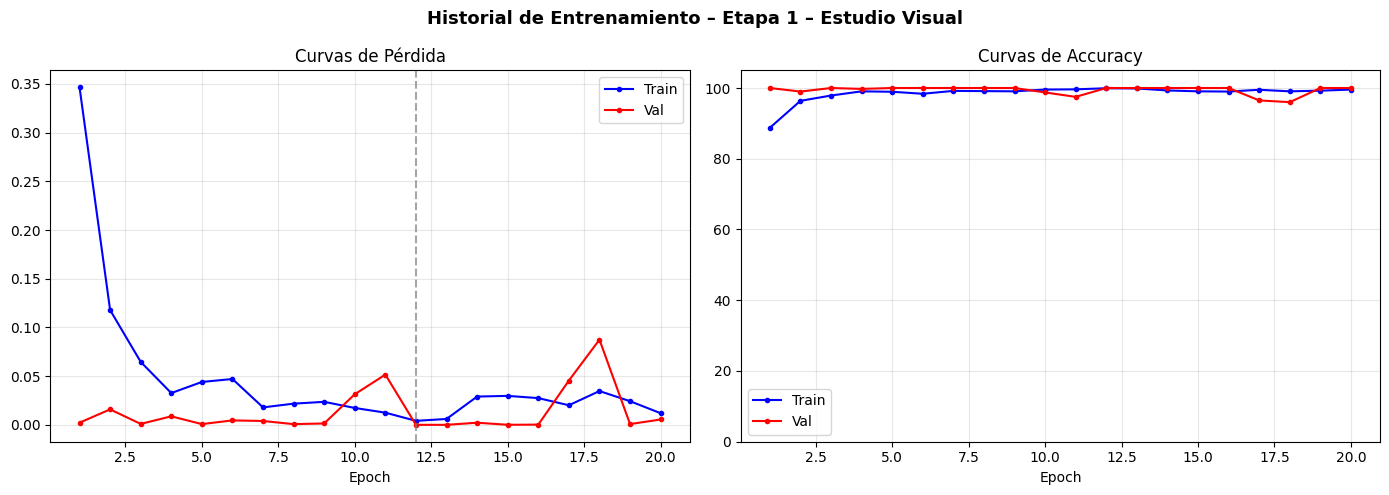

Mejor Val Accuracy: 100.00% (epoch 1)


In [15]:
def graficar_historial(hist, titulo='Etapa 1 – Estudio Visual'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(hist['train_loss'])+1)
    ax1.plot(ep, hist['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(ep, hist['val_loss'],   'r-o', ms=3, label='Val')
    ax1.axvline(x=np.argmin(hist['val_loss'])+1, color='gray', ls='--', alpha=0.7)
    ax1.set_title('Curvas de Pérdida'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, [a*100 for a in hist['train_acc']], 'b-o', ms=3, label='Train')
    ax2.plot(ep, [a*100 for a in hist['val_acc']],   'r-o', ms=3, label='Val')
    ax2.set_title('Curvas de Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim([0,105])
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(f'Historial de Entrenamiento – {titulo}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Mejor Val Accuracy: {max(hist["val_acc"])*100:.2f}% (epoch {np.argmax(hist["val_acc"])+1})')

graficar_historial(historial)


In [16]:
@torch.no_grad()
def obtener_predicciones(model, loader, device):
    model.eval()
    preds_all, labels_all = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        _, preds = out.max(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)

# Cargar mejor modelo
ckpt = torch.load(CKPT_PATH, map_location=device)
modelo.load_state_dict(ckpt['model_state_dict'])
print(f'✅ Mejor modelo cargado (epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.2%})')

preds, labels_reales = obtener_predicciones(modelo, test_loader, device)
print(f'\nTest Accuracy: {(preds==labels_reales).mean():.2%}\n')
print(classification_report(labels_reales, preds, target_names=[c.split()[0] for c in class_names]))


✅ Mejor modelo cargado (epoch 12, val_acc=100.00%)

Test Accuracy: 98.98%

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       160
      Banana       1.00      1.00      1.00       166
      Cherry       1.00      1.00      1.00       164
       Grape       1.00      0.97      0.98       328
  Strawberry       0.94      1.00      0.97       164

    accuracy                           0.99       982
   macro avg       0.99      0.99      0.99       982
weighted avg       0.99      0.99      0.99       982



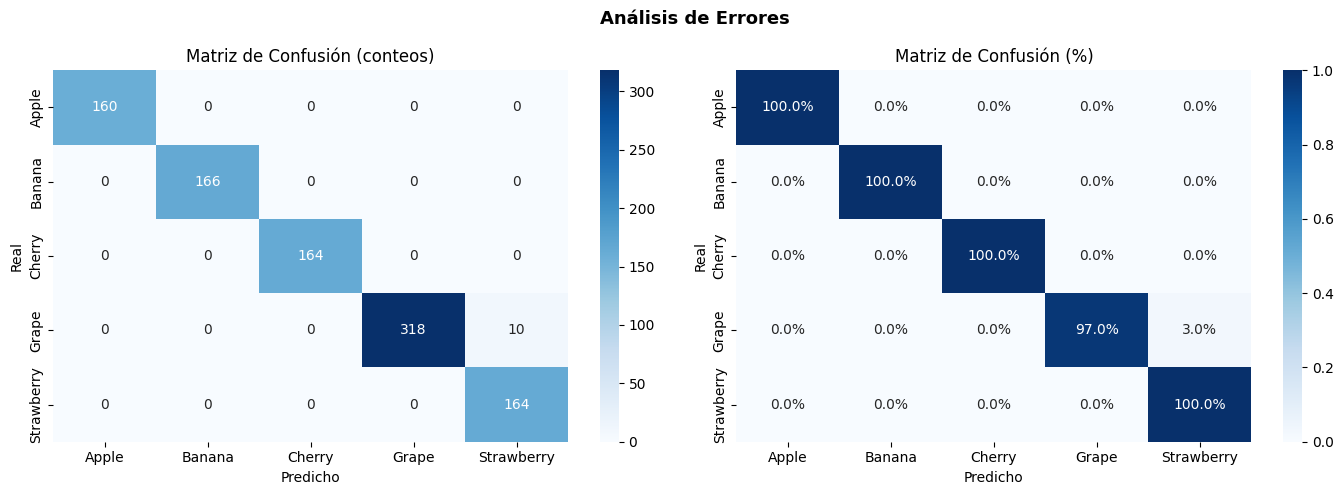

In [17]:
def graficar_confusion(preds, labels, class_names):
    nombres = [c.split()[0] for c in class_names]
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', xticklabels=nombres, yticklabels=nombres, ax=ax1)
    sns.heatmap(cm_norm, annot=True, fmt='.1%',  cmap='Blues', xticklabels=nombres, yticklabels=nombres, ax=ax2)
    ax1.set_title('Matriz de Confusión (conteos)');   ax1.set_ylabel('Real'); ax1.set_xlabel('Predicho')
    ax2.set_title('Matriz de Confusión (%)');        ax2.set_ylabel('Real'); ax2.set_xlabel('Predicho')
    plt.suptitle('Análisis de Errores', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

graficar_confusion(preds, labels_reales, class_names)


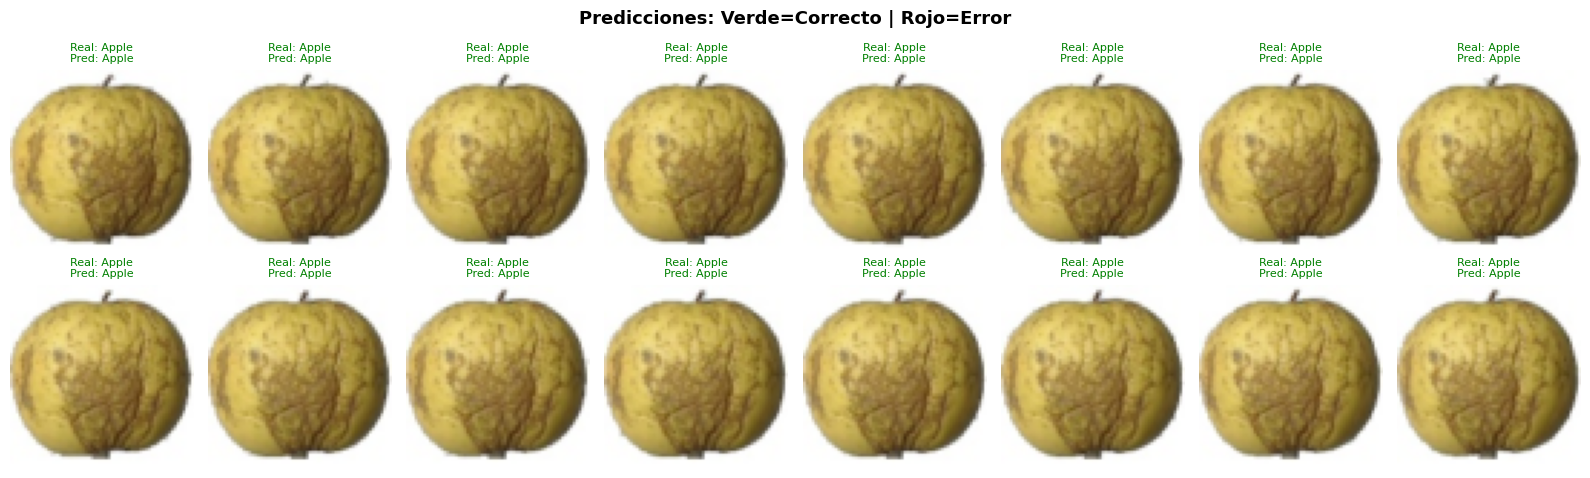

In [18]:
def visualizar_predicciones(model, loader, class_names, device, n=16):
    """Muestra predicciones: verde=correcto, rojo=error."""
    model.eval()
    imgs_b, labels_b = next(iter(loader))
    with torch.no_grad():
        _, preds = model(imgs_b.to(device)).max(1)
    mean = torch.tensor(MEAN).view(3,1,1); std = torch.tensor(STD).view(3,1,1)
    imgs_d = (imgs_b * std + mean).clamp(0, 1)
    nombres = [c.split()[0] for c in class_names]
    cols = 8; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2.5))
    axes = axes.flatten()
    for i in range(min(n, len(imgs_d))):
        img = imgs_d[i].permute(1,2,0).numpy()
        real  = nombres[labels_b[i]]
        pred  = nombres[preds[i].cpu()]
        ok = (labels_b[i] == preds[i].cpu())
        axes[i].imshow(img)
        axes[i].set_title(f'Real: {real}\nPred: {pred}', fontsize=8, color='green' if ok else 'red', fontweight='bold' if not ok else 'normal')
        axes[i].axis('off')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.suptitle('Predicciones: Verde=Correcto | Rojo=Error', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar_predicciones(modelo, test_loader, class_names, device)


---
# 🍓 ETAPA 2: Dataset UTN-IA 2026
## El desafío de generalización

Usamos el mismo modelo con un dataset con fondos variables e iluminación real.
El modelo obtendrá **peor desempeño**. Esta es la lección más importante:

> **El dataset determina tanto o más que la arquitectura.**

**Dataset:** UTN-IA 2026 · Food Classification - Training Set  
**Link:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set  
**Licencia:** Apache 2.0

> ⚠️ Este es el **dataset oficial de la competencia**. Las imágenes de test tienen fondos variados — el mismo modelo que obtuvo ~95% en Etapa 1 verá aquí cómo la distribución del dataset impacta el rendimiento real.


In [19]:
!kaggle datasets download -d geronimoforconi/utn-ia-2026-food-classification-training-set \
    -p /kaggle/input/datasets/juancruzmondino/datos-necesarios/fruit_recognition --unzip -q
print("✅ Dataset UTN-IA 2026 descargado")

raiz_r = Path("/kaggle/input/datasets/juancruzmondino/datos-necesarios/fruit_recognition")


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set
License(s): apache-2.0
[Errno 30] Read-only file system: '/kaggle/input/datasets/juancruzmondino/datos-necesarios/fruit_recognition/utn-ia-2026-food-classification-training-set.zip'
✅ Dataset UTN-IA 2026 descargado


## Etapa 2: UTN-IA 2026 · Food Classification - Training Set

In [20]:
# ============================================================
# Etapa 2: UTN-IA 2026 · Food Classification - Training Set
# El dataset tiene solo imágenes de train → dividimos en train/val/test
# ============================================================
import shutil, random
from pathlib import Path

RAIZ_FOOD = Path('/kaggle/input/datasets/juancruzmondino/datos-necesarios/fruit_recognition')
BASE_DIR_R = Path('/kaggle/working/fruit_recognition_splint/')
CLASES_R   = ['apple', 'banana', 'grapes', 'potato', 'tomato']

# Proporciones del split (deben sumar 1.0)
SPLIT_TRAIN = 0.70
SPLIT_VAL   = 0.15
SPLIT_TEST  = 0.15

if BASE_DIR_R.exists():
    shutil.rmtree(BASE_DIR_R)

def crear_subset_desde_train(clases, raiz, destino, split_train=0.70, split_val=0.15):
    """
    Busca imágenes bajo raiz/<clase>/ o raiz/train/<clase>/,
    hace split estratificado y copia a destino/train|val|test/<clase>/.
    """
    # Detectar si las clases están directamente o bajo una subcarpeta 'train/'
    probe = raiz / clases[0]
    src_base = raiz if probe.exists() else raiz / 'train'

    for clase in clases:
        imgs = sorted([
            p for p in (src_base / clase).glob('**/*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ])
        if not imgs:
            print(f'⚠️  Sin imágenes para clase "{clase}" en {src_base}')
            continue

        random.shuffle(imgs)
        n = len(imgs)
        n_val  = int(n * split_val)
        n_test = int(n * (1 - split_train - split_val))

        splits = {
            'val':   imgs[:n_val],
            'test':  imgs[n_val:n_val + n_test],
            'train': imgs[n_val + n_test:],
        }

        for split_name, subset in splits.items():
            dst = destino / split_name / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in subset:
                shutil.copy(img, dst / img.name)

        print(f'  {clase}: {len(splits["train"])} train | {len(splits["val"])} val | {len(splits["test"])} test')

    print(f'\n✅ Split creado en {destino}')

crear_subset_desde_train(CLASES_R, RAIZ_FOOD, BASE_DIR_R, SPLIT_TRAIN, SPLIT_VAL)

  apple: 39 train | 7 val | 7 test
  banana: 42 train | 9 val | 9 test
  grapes: 56 train | 11 val | 11 test
  potato: 44 train | 9 val | 9 test
  tomato: 52 train | 10 val | 10 test

✅ Split creado en /kaggle/working/fruit_recognition_splint


## Seleccionar mismas frutas que en Etapa 1 para comparación directa


✅ Subset realista creado


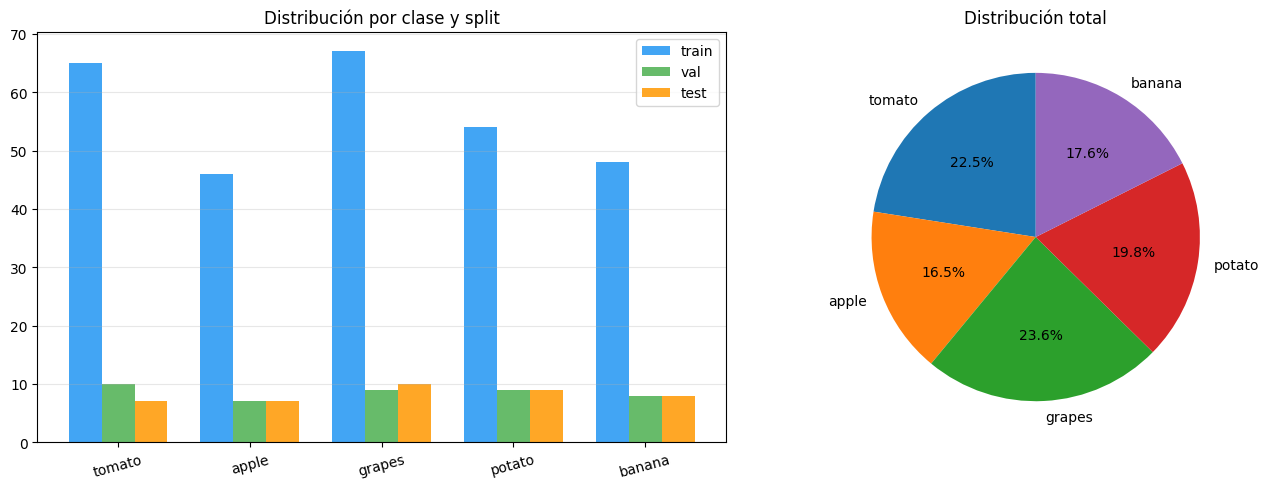

Clase                     Train      Val     Test
--------------------------------------------------
tomato                       65       10        7
apple                        46        7        7
grapes                       67        9       10
potato                       54        9        9
banana                       48        8        8


In [21]:
for split, split_src_name in [('train','train'), ('val','validation'), ('test','test')]:
    src_base = raiz_r / split_src_name
    if not src_base.exists(): continue
    for clase in CLASES_R:
        src = src_base / clase
        if src.exists():
            dst = BASE_DIR_R / split / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in src.glob('*.*'):
                if img.suffix.lower() in ['.jpg','.jpeg','.png']:
                    shutil.copy(img, dst / img.name)

print('✅ Subset realista creado')
analizar_distribucion(BASE_DIR_R)


## Comparación visual: Etapa 1 (Estudio Visual) vs Etapa 2 (Training Set)


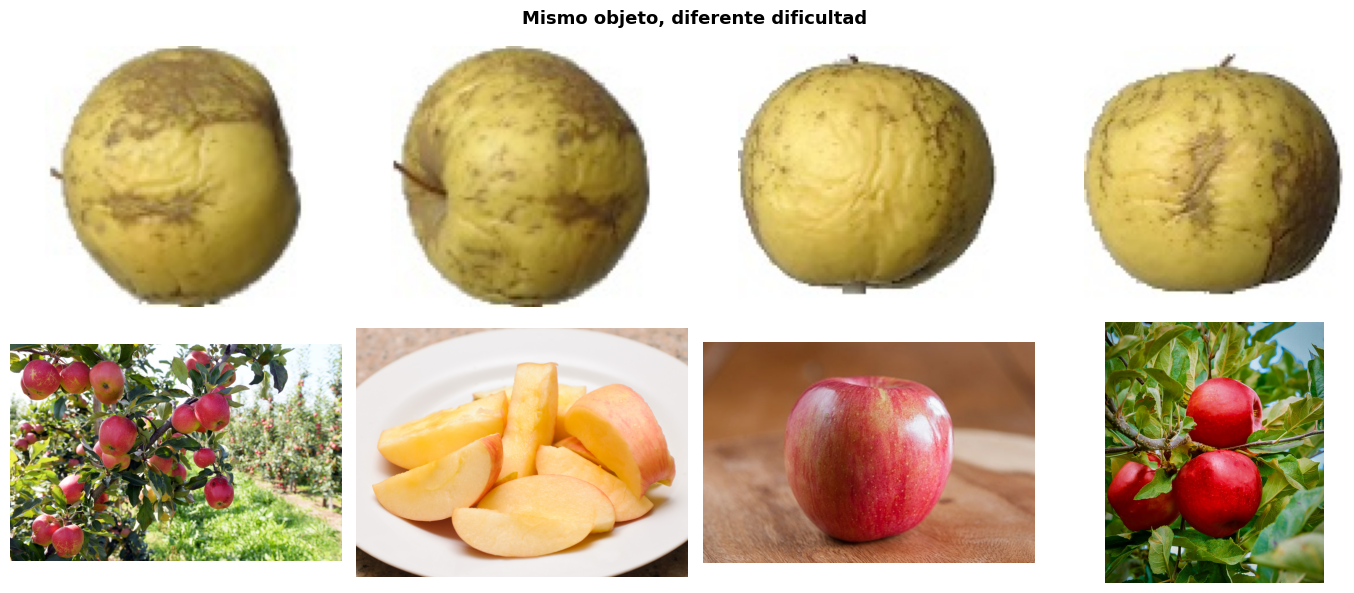

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for row, (base, clase, titulo) in enumerate([
    (BASE_DIR,   CLASES_SELECCIONADAS[0], 'UTN-IA 2026 · Estudio Visual - Etapa 1'),
    (BASE_DIR_R, CLASES_R[0],             'Dataset Realista')
]):
    carpeta = base / 'train' / clase
    imgs = list(carpeta.glob('*.jpg'))[:4] or list(carpeta.glob('*.png'))[:4]
    for col, img_path in enumerate(imgs[:4]):
        axes[row][col].imshow(Image.open(img_path))
        axes[row][col].axis('off')
        if col == 0: axes[row][col].set_ylabel(titulo, fontsize=10, fontweight='bold')
plt.suptitle('Mismo objeto, diferente dificultad', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Augmentation

In [23]:
# Augmentation más agresivo para el dataset realista (pocos datos, más variabilidad)
transform_train_r = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

#algunas imagenes estaban con formato transparente

from PIL import Image

def cargar_imagen_limpia(path):
    img = Image.open(path)
    # Convertir formatos problemáticos a RGB estándar
    if img.mode in ('P', 'RGBA', 'LA'):
        img = img.convert('RGBA')
        fondo = Image.new('RGB', img.size, (255, 255, 255))
        fondo.paste(img, mask=img.split()[3])  # usar canal alpha como máscara
        return fondo
    return img.convert('RGB')

train_r = ImageFolder(str(BASE_DIR_R/'train'), transform=transform_train_r,
                      loader=cargar_imagen_limpia)
val_r   = ImageFolder(str(BASE_DIR_R/'val'),   transform=transform_base,
                      loader=cargar_imagen_limpia)
test_r  = ImageFolder(str(BASE_DIR_R/'test'),  transform=transform_base,
                      loader=cargar_imagen_limpia)

train_loader_r = DataLoader(train_r, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_r   = DataLoader(val_r,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_r  = DataLoader(test_r,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names_r = train_r.classes
print(f'✅ Dataset realista: train={len(train_r)} | val={len(val_r)} | test={len(test_r)}')


✅ Dataset realista: train=325 | val=46 | test=46


## Entrenar el MISMO modelo en el dataset realista


In [24]:
modelo_r = FrutasCNN(num_classes=len(class_names_r)).to(device)
optimizer_r = optim.Adam(modelo_r.parameters(), lr=1e-3, weight_decay=1e-3)  # mayor regularización
scheduler_r = optim.lr_scheduler.ReduceLROnPlateau(optimizer_r, patience=5, factor=0.5)

historial_r = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}
mejor_r = float('inf'); 
CKPT_R = '/kaggle/working/mejor_modelo_realista.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10} | {"Val F1":>10}')
print('-'*58)

for epoch in range(1, EPOCHS+1):
    tl, ta = entrenar_epoch(modelo_r, train_loader_r, criterion, optimizer_r, device)
    vl, va, vf1 = evaluar(modelo_r, val_loader_r, criterion, device)
    scheduler_r.step(vl)
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va),('val_f1',vf1)]:
        historial_r[k].append(v)
    marca = ''
    if vl < mejor_r:
        mejor_r = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo_r.state_dict(), 'val_acc':va, 'val_f1':vf1}, CKPT_R)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%} | {vf1:>9.1%}{marca}')


 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc |     Val F1
----------------------------------------------------------
     1 |     2.6090 |     28.9% |     1.2831 |     52.2% |     47.4% ✅
     2 |     1.7439 |     37.5% |     1.2870 |     43.5% |     35.0%
     3 |     1.4807 |     39.7% |     1.2388 |     47.8% |     42.7% ✅
     4 |     1.4246 |     40.0% |     1.2141 |     54.3% |     49.2% ✅
     5 |     1.3148 |     44.9% |     1.1796 |     63.0% |     62.6% ✅
     6 |     1.4185 |     44.9% |     1.1338 |     63.0% |     62.1% ✅
     7 |     1.3105 |     43.1% |     1.0917 |     63.0% |     60.0% ✅
     8 |     1.2643 |     48.6% |     1.0610 |     63.0% |     60.9% ✅
     9 |     1.3631 |     44.0% |     1.0533 |     71.7% |     70.8% ✅
    10 |     1.2903 |     45.5% |     1.0773 |     67.4% |     65.2%
    11 |     1.2561 |     45.5% |     1.0150 |     63.0% |     58.9% ✅
    12 |     1.1744 |     50.5% |     0.9147 |     69.6% |     69.1% ✅
    13 |     1.2085 |

# Comparación final: Dataset controlado vs. Realista

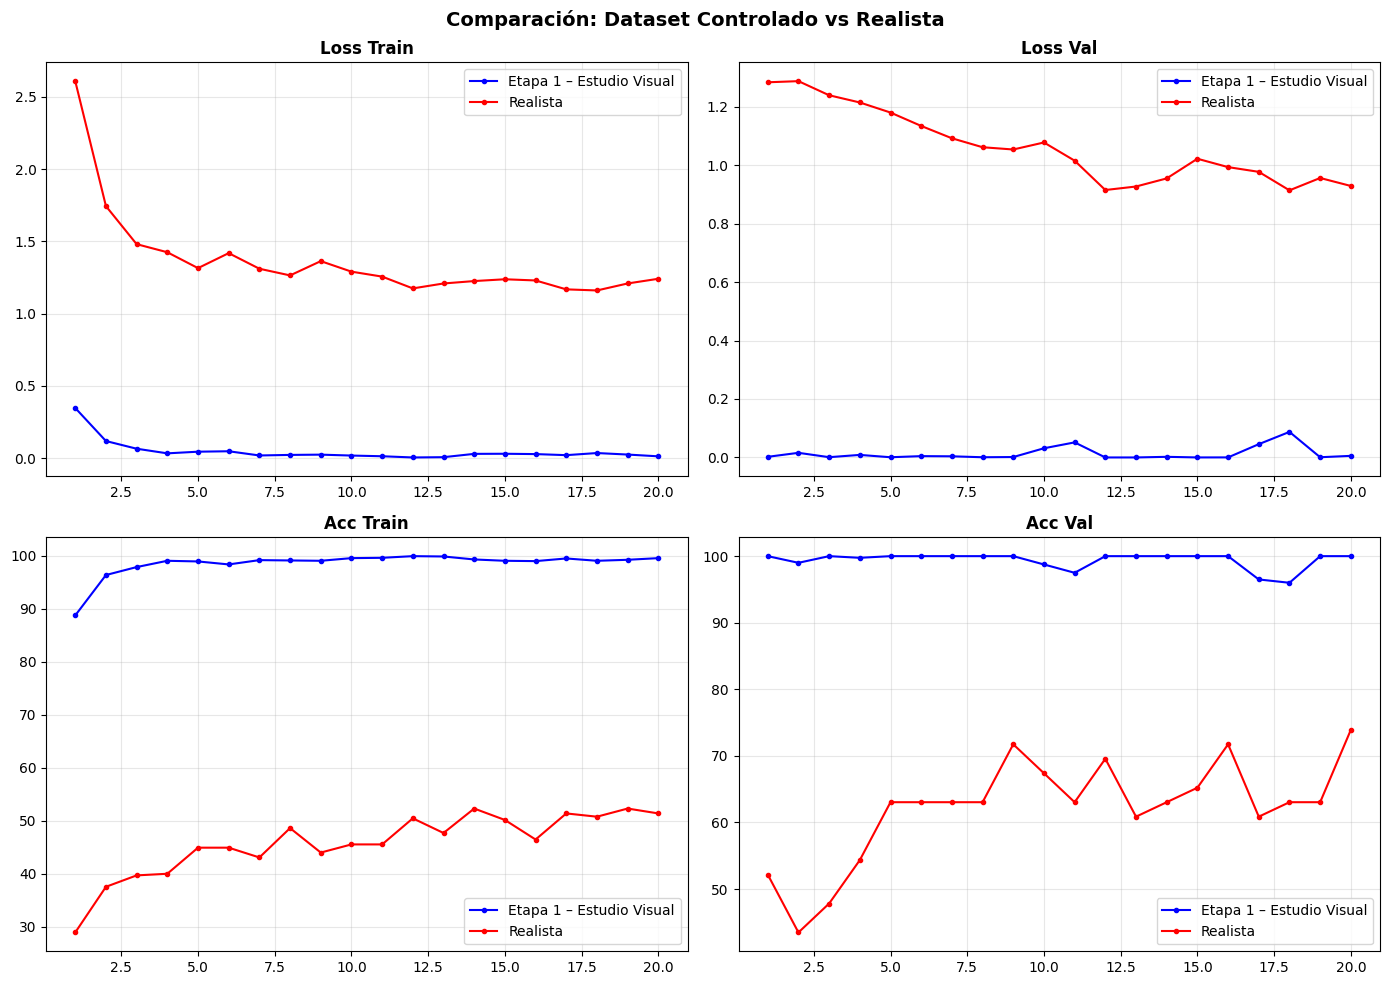

Dataset              Best Val Acc  Best Val Loss
------------------------------------------------
Etapa 1 – Estudio Visual      100.00%         0.0000
Realista                   73.91%         0.9136


In [25]:
def comparar_resultados(h1, h2, label1='Etapa 1 – Estudio Visual', label2='Realista'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    keys = [('train_loss','Loss Train'),('val_loss','Loss Val'),('train_acc','Acc Train'),('val_acc','Acc Val')]
    for ax, (key, titulo) in zip(axes.flatten(), keys):
        v1 = [x*100 for x in h1[key]] if 'acc' in key else h1[key]
        v2 = [x*100 for x in h2[key]] if 'acc' in key else h2[key]
        ax.plot(range(1,len(v1)+1), v1, 'b-o', ms=3, label=label1)
        ax.plot(range(1,len(v2)+1), v2, 'r-o', ms=3, label=label2)
        ax.set_title(titulo, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Comparación: Dataset Controlado vs Realista', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'{"Dataset":<20} {"Best Val Acc":>12} {"Best Val Loss":>14}')
    print('-'*48)
    print(f'{label1:<20} {max(h1["val_acc"])*100:>11.2f}% {min(h1["val_loss"]):>14.4f}')
    print(f'{label2:<20} {max(h2["val_acc"])*100:>11.2f}% {min(h2["val_loss"]):>14.4f}')

comparar_resultados(historial, historial_r)



# 🎓 PREGUNTAS PARA LA CLASE:
  1. ¿Por qué el mismo modelo obtiene resultados tan diferentes?
  2. ¿Qué estrategias usarías para mejorar el modelo realista?
  3. ¿Por qué el augmentation más agresivo ayuda más en Etapa 2?
  4. ¿Qué es transfer learning y cómo ayudaría aquí?


In [26]:
# ============================================================
# ETAPA 3: Transfer Learning — Configuración
# ============================================================
import torchvision.models as models

IMG_SIZE_TL   = 224          # tamaño esperado por los modelos preentrenados
BATCH_SIZE_TL = 32           

transform_tl_train = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL + 32, IMG_SIZE_TL + 32)),
    transforms.RandomCrop(IMG_SIZE_TL),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

transform_tl_base = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print('✅ Transformaciones para Transfer Learning definidas (224x224, estadísticas ImageNet)')

✅ Transformaciones para Transfer Learning definidas (224x224, estadísticas ImageNet)


---
# 🔄 ETAPA 3: Transfer Learning
## Aprovechando modelos preentrenados en ImageNet

Hasta ahora entrenamos `FrutasCNN` desde cero. Un modelo preentrenado en ImageNet (1000 clases, millones de imágenes) ya "sabe ver" bordes, texturas, formas y partes de objetos. Solo necesitamos adaptar la última capa a nuestras 5 clases de frutas/verduras.

Comparamos 3 arquitecturas sobre el dataset realista (Etapa 2):

| Modelo | Tipo | Parámetros (aprox.) |
|---|---|---|
| **ResNet18** | CNN con conexiones residuales | 11M |
| **EfficientNet-B0** | CNN escalada de forma balanceada (profundidad / ancho / resolución) | 5M |
| **ViT-B/16** | Vision Transformer (divide la imagen en parches de 16×16) | 86M |

**Estrategia (transfer learning "feature extraction"):**
1. Cargar el modelo con sus pesos de ImageNet.
2. **Congelar** todas las capas del backbone (no se actualizan sus pesos).
3. Reemplazar la última capa por una nueva, con salida = número de clases del problema.
4. Entrenar **solo** esa última capa.

In [27]:
# Usamos el dataset REALISTA (Etapa 2)
train_tl = ImageFolder(str(BASE_DIR_R / 'train'), transform=transform_tl_train, loader=cargar_imagen_limpia)
val_tl   = ImageFolder(str(BASE_DIR_R / 'val'),   transform=transform_tl_base,  loader=cargar_imagen_limpia)
test_tl  = ImageFolder(str(BASE_DIR_R / 'test'),  transform=transform_tl_base,  loader=cargar_imagen_limpia)

train_loader_tl = DataLoader(train_tl, batch_size=BATCH_SIZE_TL, shuffle=True,  num_workers=0, pin_memory=False)
val_loader_tl   = DataLoader(val_tl,   batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=0, pin_memory=False)
test_loader_tl  = DataLoader(test_tl,  batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=0, pin_memory=False)

class_names_tl = train_tl.classes
print(f'✅ Dataset TL ({IMG_SIZE_TL}x{IMG_SIZE_TL}): train={len(train_tl)} | val={len(val_tl)} | test={len(test_tl)}')
print(f'   Clases: {class_names_tl}')

✅ Dataset TL (224x224): train=325 | val=46 | test=46
   Clases: ['apple', 'banana', 'grapes', 'potato', 'tomato']


In [28]:
def crear_modelo_transfer(nombre_modelo, num_classes, congelar_backbone=True):
    """
    Crea un modelo preentrenado en ImageNet y adapta su última capa
    al número de clases del problema (transfer learning).

    nombre_modelo: 'resnet18' | 'efficientnet_b0' | 'vit_b_16'
    congelar_backbone: si True, congela el backbone y solo se entrena la nueva capa final
    """
    if nombre_modelo == 'resnet18':
        modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if congelar_backbone:
            for p in modelo.parameters():
                p.requires_grad = False
        modelo.fc = nn.Linear(modelo.fc.in_features, num_classes)   # nueva capa final (entrenable)

    elif nombre_modelo == 'efficientnet_b0':
        modelo = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if congelar_backbone:
            for p in modelo.parameters():
                p.requires_grad = False
        modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, num_classes)

    elif nombre_modelo == 'vit_b_16':
        modelo = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        if congelar_backbone:
            for p in modelo.parameters():
                p.requires_grad = False
        modelo.heads.head = nn.Linear(modelo.heads.head.in_features, num_classes)

    else:
        raise ValueError(f'Modelo no soportado: {nombre_modelo}')

    return modelo.to(device)


def contar_parametros(modelo, nombre):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    print(f'{nombre:20s}: {total:>12,} parámetros totales | {entrenables:>10,} entrenables ({entrenables/total:.1%})')

In [29]:
modelo_resnet18     = crear_modelo_transfer('resnet18',        num_classes=len(class_names_tl))
modelo_efficientnet = crear_modelo_transfer('efficientnet_b0', num_classes=len(class_names_tl))
modelo_vit          = crear_modelo_transfer('vit_b_16',        num_classes=len(class_names_tl))

contar_parametros(modelo_resnet18,     'ResNet18')
contar_parametros(modelo_efficientnet, 'EfficientNet-B0')
contar_parametros(modelo_vit,          'ViT-B/16')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s] 


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 211MB/s]  


ResNet18            :   11,179,077 parámetros totales |      2,565 entrenables (0.0%)
EfficientNet-B0     :    4,013,953 parámetros totales |      6,405 entrenables (0.2%)
ViT-B/16            :   85,802,501 parámetros totales |      3,845 entrenables (0.0%)


In [30]:
# Test rápido: verificar que las 3 arquitecturas devuelven la forma esperada
with torch.no_grad():
    x_tl = torch.randn(2, 3, IMG_SIZE_TL, IMG_SIZE_TL).to(device)
    for nombre, m in [('ResNet18', modelo_resnet18), ('EfficientNet-B0', modelo_efficientnet), ('ViT-B/16', modelo_vit)]:
        salida = m(x_tl)
        print(f'{nombre:20s} → entrada {tuple(x_tl.shape)} | salida {tuple(salida.shape)}')

ResNet18             → entrada (2, 3, 224, 224) | salida (2, 5)
EfficientNet-B0      → entrada (2, 3, 224, 224) | salida (2, 5)
ViT-B/16             → entrada (2, 3, 224, 224) | salida (2, 5)


In [31]:
EPOCHS_TL = 20
LR_TL     = 1e-3

def entrenar_modelo_tl(modelo, nombre, epochs=EPOCHS_TL, lr=LR_TL):
    """Entrena solo los parámetros con requires_grad=True (la nueva cabeza)."""
    criterion_tl = nn.CrossEntropyLoss()
    params_entrenables = filter(lambda p: p.requires_grad, modelo.parameters())
    optimizer_tl = optim.Adam(params_entrenables, lr=lr, weight_decay=1e-4)
    scheduler_tl = optim.lr_scheduler.ReduceLROnPlateau(optimizer_tl, patience=3, factor=0.5)

    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
    mejor_val_loss = float('inf')
    ckpt_path = f'/kaggle/working/mejor_{nombre}.pth'

    print(f'\n🔵 Entrenando {nombre} (transfer learning)')
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10} | {"Val F1":>10}')
    print('-' * 70)

    for epoch in range(1, epochs + 1):
        tloss, tacc = entrenar_epoch(modelo, train_loader_tl, criterion_tl, optimizer_tl, device)
        vloss, vacc, vf1 = evaluar(modelo, val_loader_tl, criterion_tl, device)
        scheduler_tl.step(vloss)
        for k, v in [('train_loss', tloss), ('val_loss', vloss), ('train_acc', tacc), ('val_acc', vacc), ('val_f1', vf1)]:
            historial[k].append(v)
        marca = ''
        if vloss < mejor_val_loss:
            mejor_val_loss = vloss
            torch.save({'epoch': epoch, 'model_state_dict': modelo.state_dict(), 'val_acc': vacc, 'val_f1': vf1}, ckpt_path)
            marca = ' ✅'
        print(f'{epoch:>6} | {tloss:>10.4f} | {tacc:>9.1%} | {vloss:>10.4f} | {vacc:>9.1%} | {vf1:>9.1%}{marca}')

    return historial, ckpt_path

In [32]:
historial_resnet, ckpt_resnet = entrenar_modelo_tl(modelo_resnet18, 'resnet18')


🔵 Entrenando resnet18 (transfer learning)
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc |     Val F1
----------------------------------------------------------------------
     1 |     1.5639 |     33.2% |     1.2215 |     43.5% |     39.5% ✅
     2 |     1.1247 |     65.2% |     0.8009 |     73.9% |     72.7% ✅
     3 |     0.8885 |     73.5% |     0.6010 |     82.6% |     80.4% ✅
     4 |     0.6868 |     83.7% |     0.4867 |     93.5% |     93.5% ✅
     5 |     0.5412 |     90.5% |     0.4008 |     93.5% |     93.6% ✅
     6 |     0.4913 |     90.2% |     0.3401 |     95.7% |     95.7% ✅
     7 |     0.4295 |     92.3% |     0.3221 |     95.7% |     95.7% ✅
     8 |     0.3824 |     92.3% |     0.2545 |     95.7% |     95.7% ✅
     9 |     0.3607 |     91.4% |     0.2713 |     95.7% |     95.7%
    10 |     0.3689 |     92.0% |     0.2329 |     95.7% |     95.7% ✅
    11 |     0.3692 |     91.7% |     0.2127 |     95.7% |     95.7% ✅
    12 |     0.3161 |     92.0% |  

In [33]:
historial_efficientnet, ckpt_efficientnet = entrenar_modelo_tl(modelo_efficientnet, 'efficientnet_b0')


🔵 Entrenando efficientnet_b0 (transfer learning)
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc |     Val F1
----------------------------------------------------------------------
     1 |     1.3719 |     53.8% |     0.9728 |     87.0% |     86.2% ✅
     2 |     0.9092 |     84.0% |     0.6543 |     91.3% |     91.3% ✅
     3 |     0.7018 |     87.1% |     0.4884 |     93.5% |     93.6% ✅
     4 |     0.5511 |     88.9% |     0.3906 |     95.7% |     95.5% ✅
     5 |     0.4748 |     90.8% |     0.3324 |     97.8% |     97.5% ✅
     6 |     0.4139 |     90.5% |     0.2676 |     97.8% |     97.5% ✅
     7 |     0.3757 |     91.7% |     0.2363 |     97.8% |     97.5% ✅
     8 |     0.3652 |     92.9% |     0.2119 |     97.8% |     97.5% ✅
     9 |     0.3225 |     92.0% |     0.1949 |     97.8% |     97.5% ✅
    10 |     0.3069 |     94.5% |     0.1825 |     97.8% |     97.5% ✅
    11 |     0.2708 |     94.5% |     0.1664 |     97.8% |     97.5% ✅
    12 |     0.2791 |     

In [34]:
historial_vit, ckpt_vit = entrenar_modelo_tl(modelo_vit, 'vit_b_16')


🔵 Entrenando vit_b_16 (transfer learning)
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc |     Val F1
----------------------------------------------------------------------
     1 |     1.1865 |     60.9% |     0.6934 |     93.5% |     93.3% ✅
     2 |     0.5248 |     87.7% |     0.3657 |     91.3% |     91.3% ✅
     3 |     0.3213 |     93.2% |     0.2760 |     91.3% |     91.3% ✅
     4 |     0.2590 |     93.2% |     0.2303 |     93.5% |     93.3% ✅
     5 |     0.1977 |     94.5% |     0.1871 |     97.8% |     97.6% ✅
     6 |     0.1703 |     95.1% |     0.1625 |     97.8% |     97.6% ✅
     7 |     0.1488 |     97.8% |     0.1433 |     97.8% |     97.6% ✅
     8 |     0.1331 |     96.6% |     0.1206 |     97.8% |     97.6% ✅
     9 |     0.1376 |     96.3% |     0.1129 |     97.8% |     97.6% ✅
    10 |     0.1224 |     97.8% |     0.1052 |     97.8% |     97.6% ✅
    11 |     0.1075 |     98.5% |     0.0927 |     97.8% |     97.6% ✅
    12 |     0.1022 |     98.2% |

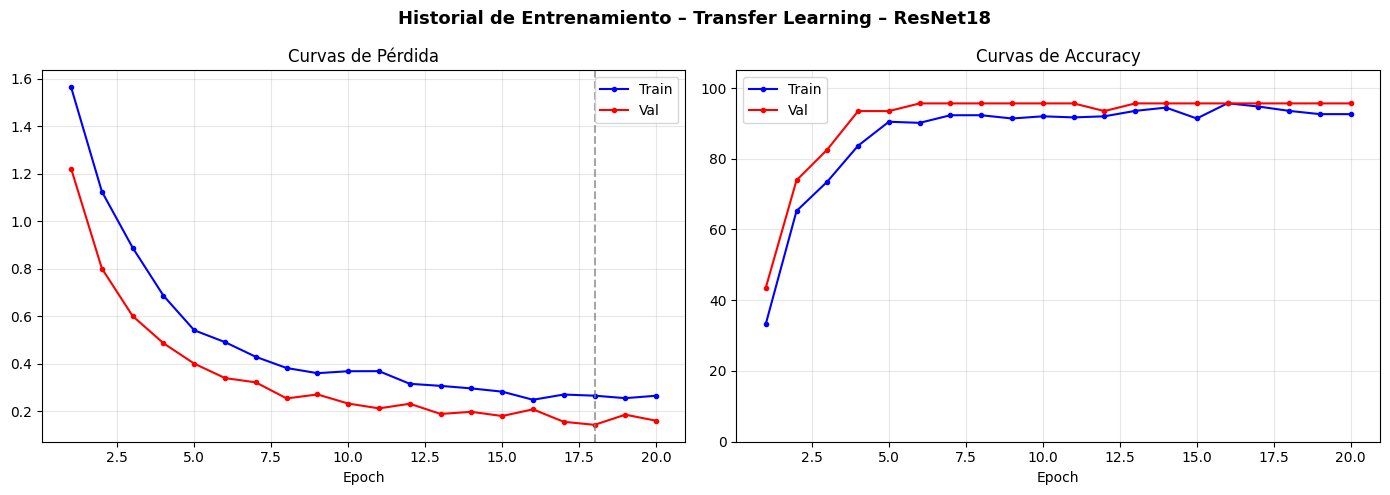

Mejor Val Accuracy: 95.65% (epoch 6)


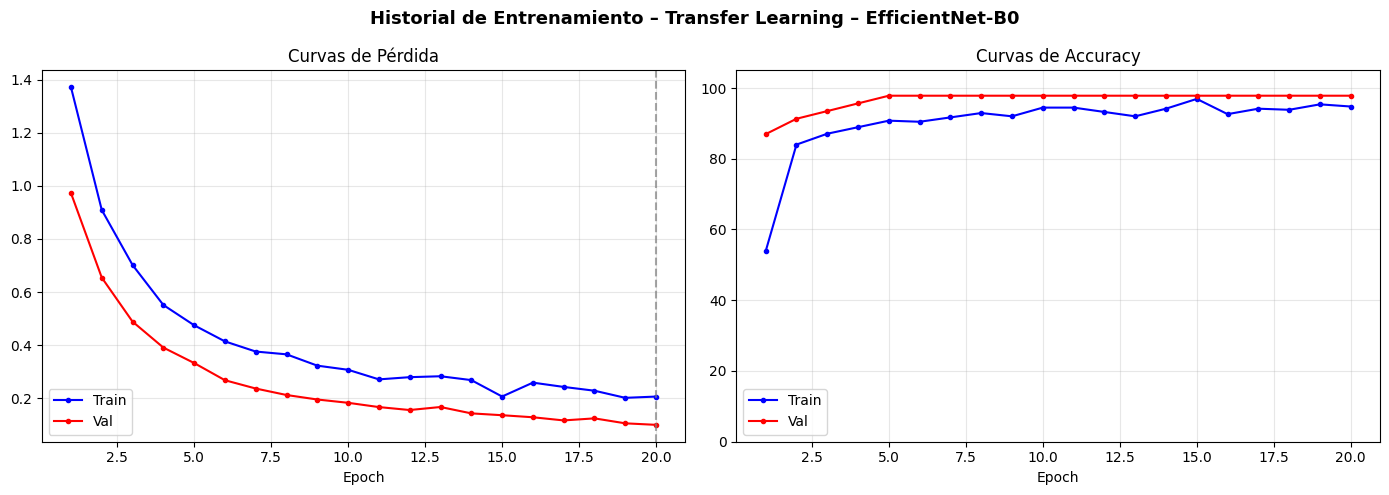

Mejor Val Accuracy: 97.83% (epoch 5)


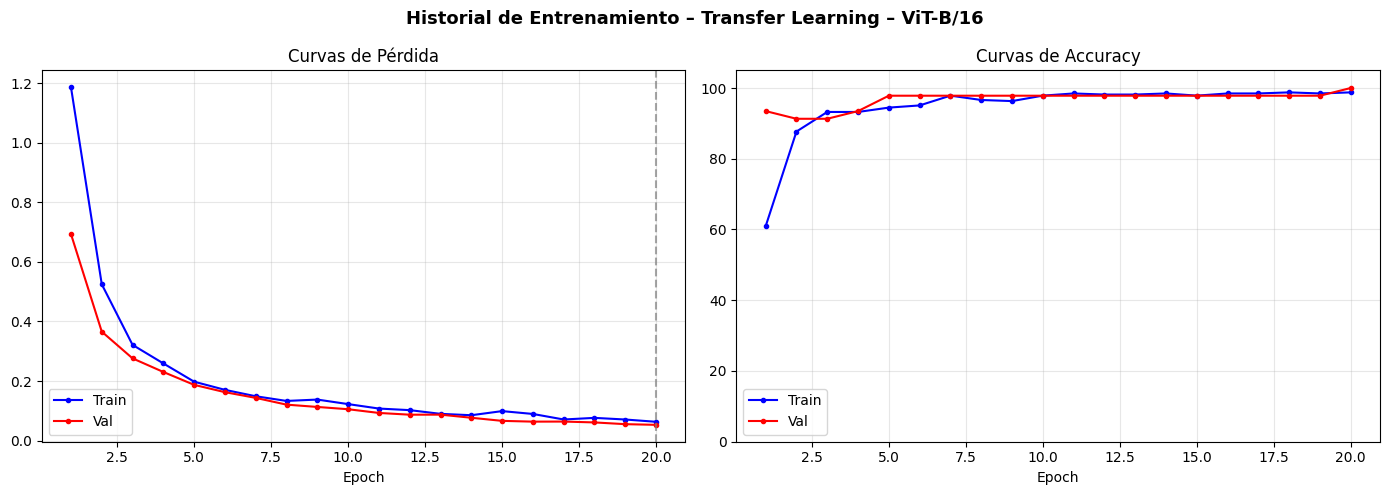

Mejor Val Accuracy: 100.00% (epoch 20)


In [35]:
graficar_historial(historial_resnet,       titulo='Transfer Learning – ResNet18')
graficar_historial(historial_efficientnet, titulo='Transfer Learning – EfficientNet-B0')
graficar_historial(historial_vit,          titulo='Transfer Learning – ViT-B/16')

In [36]:
resultados_tl = {
    'FrutasCNN desde cero (Etapa 2)': {
        'Accuracy': max(historial_r['val_acc']),
        'F1-Score': max(historial_r['val_f1']),
        'Val_Loss': min(historial_r['val_loss'])
    },
    'ResNet18 (transfer learning)': {
        'Accuracy': max(historial_resnet['val_acc']),
        'F1-Score': max(historial_resnet['val_f1']),
        'Val_Loss': min(historial_resnet['val_loss'])
    },
    'EfficientNet-B0 (transfer learning)': {
        'Accuracy': max(historial_efficientnet['val_acc']),
        'F1-Score': max(historial_efficientnet['val_f1']),
        'Val_Loss': min(historial_efficientnet['val_loss'])
    },
    'ViT-B/16 (transfer learning)': {
        'Accuracy': max(historial_vit['val_acc']),
        'F1-Score': max(historial_vit['val_f1']),
        'Val_Loss': min(historial_vit['val_loss'])
    }
}

print("Comparación de modelos\n")

print(f'{"Modelo":40s} {"Accuracy":>12s} {"F1-Score":>12s} {"Val_Loss":>12s}')
print("-"*80)

for nombre, metricas in sorted(resultados_tl.items(),
                               key=lambda x: x[1]["F1-Score"],
                               reverse=True):

    print(f'{nombre:40s} '
          f'{metricas["Accuracy"]:11.2%} '
          f'{metricas["F1-Score"]:11.2%}'
          f'{metricas["Val_Loss"]:11.4f}')

Comparación de modelos

Modelo                                       Accuracy     F1-Score     Val_Loss
--------------------------------------------------------------------------------
ViT-B/16 (transfer learning)                 100.00%     100.00%     0.0528
EfficientNet-B0 (transfer learning)           97.83%      97.51%     0.0995
ResNet18 (transfer learning)                  95.65%      95.69%     0.1434
FrutasCNN desde cero (Etapa 2)                73.91%      71.86%     0.9136


Debajo generaré un .csv para cada uno de los modelos creados.

In [37]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd
import torch

# -------------------------------
# Configuración
# -------------------------------

DIR_TEST = Path(r"/kaggle/input/datasets/juancruzmondino/datos-necesarios/test_competencia/utn_competencia_test/test_images")

imagenes_test = sorted(
    [p for p in DIR_TEST.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]
)

print(f"✅ {len(imagenes_test)} imágenes de test listas para predecir")

CLASES_COMP = ["apple", "banana", "grapes", "potato", "tomato"]

# Carpeta donde están los .pth
DIR_MODELOS = Path(r"/kaggle/working")

# Diccionario de modelos
modelos = {
    "resnet18": {
        "modelo": modelo_resnet18,
        "checkpoint": "mejor_resnet18.pth",
        "transform": transform_tl_base,
        "class_names": class_names_tl
    },

    "efficientnet_b0": {
        "modelo": modelo_efficientnet,
        "checkpoint": "mejor_efficientnet_b0.pth",
        "transform": transform_tl_base,
        "class_names": class_names_tl
    },

    "vit_b_16": {
        "modelo": modelo_vit,
        "checkpoint": "mejor_vit_b_16.pth",
        "transform": transform_tl_base,
        "class_names": class_names_tl
    },

    "cnn": {
        "modelo": modelo_r,
        "checkpoint": "mejor_modelo_realista.pth",
        "transform": transform_base,
        "class_names": class_names_r
    }
}

# -------------------------------
# Generar submissions
# -------------------------------

for nombre_modelo, info in modelos.items():

    modelo = info["modelo"]
    transform = info["transform"]
    class_names = info["class_names"]

    checkpoint = DIR_MODELOS / info["checkpoint"]

    print(f"\n==============================")
    print(f"Procesando {nombre_modelo}")
    print(f"==============================")

    if not checkpoint.exists():
        print(f"⚠ No existe {checkpoint.name}. Se omite.")
        continue

    estado = torch.load(checkpoint, map_location=device)
    modelo.load_state_dict(estado["model_state_dict"])
    modelo.to(device)
    modelo.eval()

    predicciones = []

    with torch.no_grad():

        for img_path in imagenes_test:

            img = cargar_imagen_limpia(img_path)

            tensor = transform(img).unsqueeze(0).to(device)

            salida = modelo(tensor)

            pred_idx = salida.argmax(1).item()

            pred_label = class_names[pred_idx].lower().strip()

            predicciones.append({
                "image_id": img_path.stem,
                "label": pred_label
            })

    df_sub = pd.DataFrame(predicciones)

    archivo = DIR_MODELOS / f"submission_{nombre_modelo}.csv"

    df_sub.to_csv(archivo, index=False)

    print(df_sub["label"].value_counts())

    print(f"✅ Guardado: {archivo.name}")

print("\n🎉 Todos los submissions fueron generados.")

✅ 89 imágenes de test listas para predecir

Procesando resnet18
label
grapes    21
tomato    21
apple     17
banana    17
potato    13
Name: count, dtype: int64
✅ Guardado: submission_resnet18.csv

Procesando efficientnet_b0
label
grapes    23
tomato    23
banana    16
potato    14
apple     13
Name: count, dtype: int64
✅ Guardado: submission_efficientnet_b0.csv

Procesando vit_b_16
label
tomato    22
grapes    21
banana    16
potato    16
apple     14
Name: count, dtype: int64
✅ Guardado: submission_vit_b_16.csv

Procesando cnn
label
tomato    34
grapes    25
banana    19
potato     8
apple      3
Name: count, dtype: int64
✅ Guardado: submission_cnn.csv

🎉 Todos los submissions fueron generados.


In [38]:
RESULTADOS_ETAPA3 = (
    pd.DataFrame(resultados_tl)
      .T
      .rename(columns={
          'Accuracy': 'mejor_val_accuracy',
          'F1-Score': 'mejor_val_f1',
          'Val_Loss': 'menor_val_loss'
      })
)

RESULTADOS_ETAPA3 = RESULTADOS_ETAPA3.rename(index={
    'FrutasCNN desde cero (Etapa 2)': 'cnn',
    'ResNet18 (transfer learning)': 'resnet18',
    'EfficientNet-B0 (transfer learning)': 'efficientnet_b0',
    'ViT-B/16 (transfer learning)': 'vit_b_16'
})

---
# 🏆 Submission para la Competencia Kaggle
## UTN-IA 2026: Fruit & Vegetable Classifier

Una vez entrenado el modelo en Etapa 2, generamos el archivo `submission.csv` para subirlo a la competencia.

**Competencia:** https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier

**Formato requerido:**
```
image_id,label
img_0001.jpg,apple
img_0002.jpg,tomato
...
```

**Clases válidas:** `apple`, `banana`, `grapes`, `potato`, `tomato`


In [39]:
# Crear carpeta
!mkdir \kaggle\input

# Descargar
!kaggle competitions download \
    -c utn-ia-2026-fruit-vegetable-classifier \
    -p \kaggle\input

# Renombrar
!ren \kaggle\input\utn-ia-2026-fruit-vegetable-classifier.zip utn_competencia_test.zip

# Crear carpeta destino
!mkdir \kaggle\input\test_competencia

# Descomprimir (Windows no tiene unzip)
!tar -xf \kaggle\input\utn_competencia_test.zip -C \kaggle\input\test_competencia

100%|███████████████████████████████████████| 38.9M/38.9M [00:00<00:00, 112MB/s]

/bin/bash: line 1: ren: command not found
tar: kaggleinpututn_competencia_test.zip: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [40]:
DIR_TEST = Path("/kaggle/input/datasets/juancruzmondino/datos-necesarios/test_competencia/utn_competencia_test/test_images")
imagenes_test = sorted([p for p in DIR_TEST.rglob("*") if p.suffix.lower() in [".jpg",".jpeg",".png"]])
print(f"✅ {len(imagenes_test)} imágenes de test listas para predecir")


✅ 89 imágenes de test listas para predecir


In [41]:
import pandas as pd

# Clases válidas en el mismo orden que el modelo fue entrenado
CLASES_COMP = ["apple", "banana", "grapes", "potato", "tomato"]

# Usar el modelo entrenado en Etapa 2 (modelo_r)
# Si querés usar el de Etapa 1, reemplazá modelo_r por modelo
modelo_submit = modelo_r
modelo_submit.eval()

predicciones = []

with torch.no_grad():
    for img_path in imagenes_test:
        img = Image.open(img_path).convert("RGB")
        tensor = transform_base(img).unsqueeze(0).to(device)
        logits = modelo_submit(tensor)
        pred_idx = logits.argmax(dim=1).item()
        pred_label = class_names_r[pred_idx]  # nombre de clase del modelo
        # Normalizar al nombre exacto de la competencia
        pred_label = pred_label.lower().strip()
        predicciones.append({
            "image_id": os.path.splitext(img_path.name)[0],
            "label": pred_label
        })

df_sub = pd.DataFrame(predicciones)
print(df_sub.head(10))
print(f"Distribución de predicciones:")
print(df_sub["label"].value_counts())


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


    image_id   label
0  img_00000  tomato
1  img_00001  grapes
2  img_00002  tomato
3  img_00003  banana
4  img_00004  tomato
5  img_00005  grapes
6  img_00006  banana
7  img_00007   apple
8  img_00008  grapes
9  img_00009  grapes
Distribución de predicciones:
label
tomato    34
grapes    25
banana    18
potato     9
apple      3
Name: count, dtype: int64


In [42]:
# Validar que todas las clases predichas son válidas
clases_invalidas = df_sub[~df_sub["label"].isin(CLASES_COMP)]
if len(clases_invalidas) > 0:
    print(f"⚠️ {len(clases_invalidas)} predicciones con clases inválidas:")
    print(clases_invalidas)
else:
    print(f"✅ Todas las {len(df_sub)} predicciones tienen clases válidas")

# Guardar submission.csv
df_sub.to_csv("/kaggle/working/submission.csv", index=False)
print("📄 submission.csv guardado")
print("  → Subilo en: https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier/submit")


✅ Todas las 89 predicciones tienen clases válidas
📄 submission.csv guardado
  → Subilo en: https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier/submit


---
# Mejoras avanzadas para los cuatro modelos

Esta sección aplica las mismas cuatro estrategias a `cnn`, `resnet18`,
`efficientnet_b0` y `vit_b_16` sobre el dataset realista. La CNN mantiene
imágenes de **64×64** y los modelos preentrenados usan **224×224**: no se
fuerza un único tamaño porque cambiaría la arquitectura de la CNN y las
condiciones para las que fueron entrenados los otros tres modelos.

Ejecutar las etapas en orden. Cada una guarda checkpoints independientes
dentro de `/kaggle/working/experimentos_tp1`, sin sobrescribir los
checkpoints del baseline.

In [43]:
# Configuración común para las cuatro etapas.
# Requiere haber ejecutado las Etapas 2 y 3 del notebook original.
from pathlib import Path
import math
import random
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

DIR_EXPERIMENTOS = Path('/kaggle/working/experimentos_tp1')
DIR_EXPERIMENTOS.mkdir(parents=True, exist_ok=True)

NOMBRES_MODELOS = ('cnn', 'resnet18', 'efficientnet_b0', 'vit_b_16')
CLASES_EXP = list(class_names_r)

# Cada modelo conserva el tamaño con el que fue entrenado originalmente.
ESPECIFICACION_MODELOS = {
    'cnn': {
        'tamano': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'checkpoint_base': Path(CKPT_R),
        'lr_aug': 3e-4,
        'lr_ft': 1e-4,
    },
    'resnet18': {
        'tamano': IMG_SIZE_TL,
        'batch_size': 16,
        'checkpoint_base': Path(ckpt_resnet),
        'lr_aug': 1e-4,
        'lr_ft': 3e-5,
    },
    'efficientnet_b0': {
        'tamano': IMG_SIZE_TL,
        'batch_size': 16,
        'checkpoint_base': Path(ckpt_efficientnet),
        'lr_aug': 1e-4,
        'lr_ft': 3e-5,
    },
    'vit_b_16': {
        'tamano': IMG_SIZE_TL,
        'batch_size': 8,  # ViT necesita menos memoria de GPU.
        'checkpoint_base': Path(ckpt_vit),
        'lr_aug': 2e-5,
        'lr_ft': 1e-5,
    },
}

def crear_modelo_experimento(nombre):
    """Crea una instancia nueva; así los experimentos no comparten pesos."""
    if nombre == 'cnn':
        return FrutasCNN(num_classes=len(CLASES_EXP)).to(device)
    # Se carga el checkpoint inmediatamente después, por lo que no se
    # modifican los modelos entrenados que quedaron en memoria.
    return crear_modelo_transfer(nombre, len(CLASES_EXP), congelar_backbone=False)

def cargar_modelo_experimento(nombre, checkpoint):
    checkpoint = Path(checkpoint)
    if not checkpoint.exists():
        raise FileNotFoundError(
            f'No se encontró {checkpoint}. Ejecutá primero el entrenamiento correspondiente.'
        )
    modelo = crear_modelo_experimento(nombre)
    estado = torch.load(checkpoint, map_location=device)
    modelo.load_state_dict(estado['model_state_dict'])
    return modelo.to(device)

def transform_eval(tamano):
    return transforms.Compose([
        transforms.Resize((tamano, tamano)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

def crear_loaders(nombre, transformacion_train):
    """Crea loaders nuevos para evitar mezclar resoluciones entre modelos."""
    cfg = ESPECIFICACION_MODELOS[nombre]
    tamano, batch_size = cfg['tamano'], cfg['batch_size']
    train_ds = ImageFolder(str(BASE_DIR_R / 'train'), transform=transformacion_train,
                           loader=cargar_imagen_limpia)
    val_ds = ImageFolder(str(BASE_DIR_R / 'val'), transform=transform_eval(tamano),
                         loader=cargar_imagen_limpia)
    test_ds = ImageFolder(str(BASE_DIR_R / 'test'), transform=transform_eval(tamano),
                          loader=cargar_imagen_limpia)
    if train_ds.classes != CLASES_EXP:
        raise ValueError('El orden de clases cambió; no es seguro cargar los checkpoints.')
    kwargs = dict(batch_size=batch_size, num_workers=0,
                  pin_memory=(device.type == 'cuda'))
    return (
        DataLoader(train_ds, shuffle=True, **kwargs),
        DataLoader(val_ds, shuffle=False, **kwargs),
        DataLoader(test_ds, shuffle=False, **kwargs),
    )

print('Modelos:', ', '.join(NOMBRES_MODELOS))
print('Checkpoints base:')
for nombre, cfg in ESPECIFICACION_MODELOS.items():
    print(f'  {nombre:16s} -> {cfg["checkpoint_base"]}')


Modelos: cnn, resnet18, efficientnet_b0, vit_b_16
Checkpoints base:
  cnn              -> /kaggle/working/mejor_modelo_realista.pth
  resnet18         -> /kaggle/working/mejor_resnet18.pth
  efficientnet_b0  -> /kaggle/working/mejor_efficientnet_b0.pth
  vit_b_16         -> /kaggle/working/mejor_vit_b_16.pth


## 1. Data Augmentation agresivo: RandAugment + MixUp + CutMix

`RandAugment` altera cada imagen antes de formar el batch. Luego, en cada
batch se aplica aleatoriamente **MixUp** o **CutMix** y se calcula una
pérdida con las dos etiquetas en la misma proporción que las imágenes.
Las transformaciones intensas se usan **solo en entrenamiento**; validación
y test permanecen limpios para medir generalización real.


In [44]:
# Transformación agresiva, compatible con 64×64 (CNN) y 224×224 (TL).
def transform_agresivo(tamano):
    return transforms.Compose([
        transforms.Resize((int(tamano * 1.20), int(tamano * 1.20))),
        transforms.RandomCrop(tamano),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.15),
        transforms.RandomRotation(degrees=25),
        transforms.RandAugment(num_ops=3, magnitude=9),
        transforms.ColorJitter(brightness=0.35, contrast=0.35,
                               saturation=0.25, hue=0.08),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.15),
                                 ratio=(0.3, 3.3), value='random'),
    ])

MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0
PROB_CUTMIX = 0.5  # 50% CutMix y 50% MixUp en cada batch.

def aplicar_mixup(x, y, alpha=MIXUP_ALPHA):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    indice = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[indice], y, y[indice], lam

def aplicar_cutmix(x, y, alpha=CUTMIX_ALPHA):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    indice = torch.randperm(x.size(0), device=x.device)
    _, _, alto, ancho = x.shape
    recorte = math.sqrt(1.0 - lam)
    ancho_recorte, alto_recorte = int(ancho * recorte), int(alto * recorte)
    cx = int(torch.randint(0, ancho, (1,), device=x.device).item())
    cy = int(torch.randint(0, alto, (1,), device=x.device).item())
    x1, x2 = max(cx - ancho_recorte // 2, 0), min(cx + ancho_recorte // 2, ancho)
    y1, y2 = max(cy - alto_recorte // 2, 0), min(cy + alto_recorte // 2, alto)
    x_mezclada = x.clone()
    x_mezclada[:, :, y1:y2, x1:x2] = x[indice, :, y1:y2, x1:x2]
    # Lambda real: la región puede quedar cortada contra un borde.
    lam = 1.0 - ((x2 - x1) * (y2 - y1) / (ancho * alto))
    return x_mezclada, y, y[indice], lam

def entrenar_epoch_mix(modelo, loader, optimizador, criterio, device):
    modelo.train()
    perdida_total, aciertos_suaves, total = 0.0, 0.0, 0
    for imagenes, etiquetas in loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        if random.random() < PROB_CUTMIX:
            imagenes, y_a, y_b, lam = aplicar_cutmix(imagenes, etiquetas)
        else:
            imagenes, y_a, y_b, lam = aplicar_mixup(imagenes, etiquetas)

        optimizador.zero_grad(set_to_none=True)
        logits = modelo(imagenes)
        perdida = lam * criterio(logits, y_a) + (1.0 - lam) * criterio(logits, y_b)
        perdida.backward()
        optimizador.step()

        predicciones = logits.argmax(dim=1)
        aciertos_suaves += (
            lam * predicciones.eq(y_a).sum().item()
            + (1.0 - lam) * predicciones.eq(y_b).sum().item()
        )
        perdida_total += perdida.item() * imagenes.size(0)
        total += imagenes.size(0)
    return perdida_total / total, aciertos_suaves / total

def entrenar_agresivo(nombre, epochs=12):
    cfg = ESPECIFICACION_MODELOS[nombre]
    modelo = cargar_modelo_experimento(nombre, cfg['checkpoint_base'])
    train_loader, val_loader, _ = crear_loaders(nombre, transform_agresivo(cfg['tamano']))
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.AdamW(modelo.parameters(), lr=cfg['lr_aug'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizador, mode='min', patience=3, factor=0.5
    )
    historial = {'train_loss': [], 'train_acc': [], 'val_loss': [],
                 'val_acc': [], 'val_f1': []}
    mejor_f1, mejor_loss = -1.0, float('inf')
    ruta = DIR_EXPERIMENTOS / f'mejor_agresivo_{nombre}.pth'

    print(f'\n=== {nombre}: augmentation agresivo ===')
    for epoch in range(1, epochs + 1):
        tl, ta = entrenar_epoch_mix(modelo, train_loader, optimizador, criterio, device)
        vl, va, vf1 = evaluar(modelo, val_loader, criterio, device)
        scheduler.step(vl)
        for clave, valor in [('train_loss', tl), ('train_acc', ta), ('val_loss', vl),
                              ('val_acc', va), ('val_f1', vf1)]:
            historial[clave].append(valor)
        es_mejor = vf1 > mejor_f1 or (np.isclose(vf1, mejor_f1) and vl < mejor_loss)
        if es_mejor:
            mejor_f1, mejor_loss = vf1, vl
            torch.save({'epoch': epoch, 'model_state_dict': modelo.state_dict(),
                        'val_acc': va, 'val_f1': vf1, 'class_names': CLASES_EXP}, ruta)
        print(f'Epoch {epoch:02d}/{epochs} | train_acc suave={ta:.2%} | '
              f'val_acc={va:.2%} | val_f1={vf1:.2%}' + ('  ✓' if es_mejor else ''))
    return historial, ruta


In [45]:
# Ejecutar la misma estrategia de augmentation en los cuatro modelos.
HISTORIA_AGRESIVA = {}
CHECKPOINTS_AGRESIVOS = {}
for nombre in NOMBRES_MODELOS:
    HISTORIA_AGRESIVA[nombre], CHECKPOINTS_AGRESIVOS[nombre] = entrenar_agresivo(nombre)

resultados_agresivos = pd.DataFrame({
    nombre: {
        'mejor_val_accuracy': max(historial['val_acc']),
        'mejor_val_f1': max(historial['val_f1']),
        'menor_val_loss': min(historial['val_loss']),
        'checkpoint': str(CHECKPOINTS_AGRESIVOS[nombre]),
    }
    for nombre, historial in HISTORIA_AGRESIVA.items()
}).T.sort_values('mejor_val_f1', ascending=False)
display(resultados_agresivos)

# Guardar resultados para comparaciones posteriores
RESULTADOS_AUGMENTATION = resultados_agresivos.copy()



=== cnn: augmentation agresivo ===
Epoch 01/12 | train_acc suave=39.67% | val_acc=56.52% | val_f1=48.32%  ✓
Epoch 02/12 | train_acc suave=35.20% | val_acc=58.70% | val_f1=49.03%  ✓
Epoch 03/12 | train_acc suave=38.65% | val_acc=60.87% | val_f1=51.90%  ✓
Epoch 04/12 | train_acc suave=40.30% | val_acc=67.39% | val_f1=57.36%  ✓
Epoch 05/12 | train_acc suave=40.22% | val_acc=65.22% | val_f1=55.97%
Epoch 06/12 | train_acc suave=43.18% | val_acc=60.87% | val_f1=52.82%
Epoch 07/12 | train_acc suave=42.86% | val_acc=73.91% | val_f1=67.89%  ✓
Epoch 08/12 | train_acc suave=41.67% | val_acc=76.09% | val_f1=69.02%  ✓
Epoch 09/12 | train_acc suave=40.46% | val_acc=69.57% | val_f1=63.87%
Epoch 10/12 | train_acc suave=43.11% | val_acc=69.57% | val_f1=64.17%
Epoch 11/12 | train_acc suave=40.37% | val_acc=65.22% | val_f1=62.63%
Epoch 12/12 | train_acc suave=42.82% | val_acc=60.87% | val_f1=53.19%

=== resnet18: augmentation agresivo ===
Epoch 01/12 | train_acc suave=68.27% | val_acc=100.00% | val_f1=1

,mejor_val_accuracy,mejor_val_f1,menor_val_loss,checkpoint
resnet18,1.0,1.0,0.083919,/kaggle/working/experimentos_tp1/mejor_agresiv...
efficientnet_b0,1.0,1.0,0.081915,/kaggle/working/experimentos_tp1/mejor_agresiv...
vit_b_16,1.0,1.0,0.011619,/kaggle/working/experimentos_tp1/mejor_agresiv...
cnn,0.76087,0.690193,0.90685,/kaggle/working/experimentos_tp1/mejor_agresiv...


In [46]:
# Comparación
comparacion_aug = RESULTADOS_ETAPA3[
    ['mejor_val_accuracy','mejor_val_f1','menor_val_loss']
].rename(columns={
    'mejor_val_accuracy':'Accuracy Antes',
    'mejor_val_f1':'F1 Antes',
    'menor_val_loss':'Loss Antes'
})

comparacion_aug['Accuracy Después'] = RESULTADOS_AUGMENTATION['mejor_val_accuracy']
comparacion_aug['F1 Después'] = RESULTADOS_AUGMENTATION['mejor_val_f1']
comparacion_aug['Loss Después'] = RESULTADOS_AUGMENTATION['menor_val_loss']

comparacion_aug['Δ Accuracy'] = comparacion_aug['Accuracy Después']-comparacion_aug['Accuracy Antes']
comparacion_aug['Δ F1'] = comparacion_aug['F1 Después']-comparacion_aug['F1 Antes']
comparacion_aug['Δ Loss'] = comparacion_aug['Loss Después']-comparacion_aug['Loss Antes']

display(comparacion_aug.round(4))

,Accuracy Antes,F1 Antes,Loss Antes,Accuracy Después,F1 Después,Loss Después,Δ Accuracy,Δ F1,Δ Loss
cnn,0.7391,0.7186,0.9136,0.76087,0.690193,0.90685,0.021739,-0.028366,-0.006741
resnet18,0.9565,0.9569,0.1434,1.0,1.0,0.083919,0.043478,0.04309,-0.059441
efficientnet_b0,0.9783,0.9751,0.0995,1.0,1.0,0.081915,0.021739,0.024908,-0.017546
vit_b_16,1.0000,1.0000,0.0528,1.0,1.0,0.011619,0.0,0.0,-0.041174


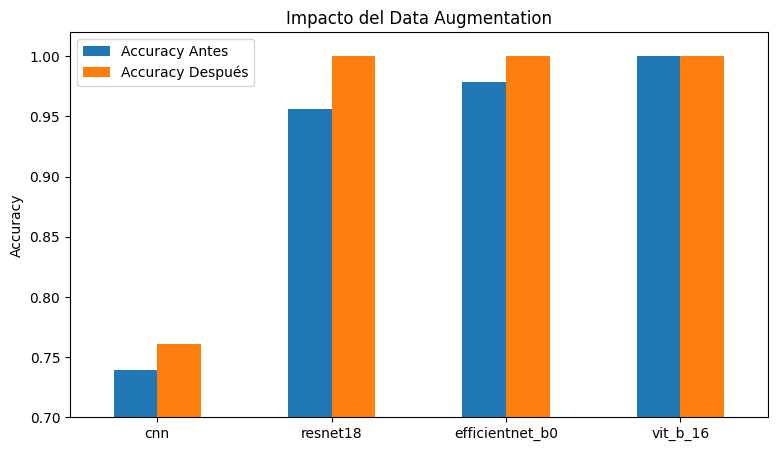

In [47]:
# Gráfico
ax = comparacion_aug[['Accuracy Antes','Accuracy Después']].plot(
    kind='bar',
    figsize=(9,5),
    rot=0
)

ax.set_ylim(0.7,1.02)
ax.set_ylabel("Accuracy")
ax.set_title("Impacto del Data Augmentation")
plt.show()

## 2. Fine-Tuning con descongelamiento progresivo

Esta etapa empieza desde el mejor checkpoint con augmentation. Se congelan
todos los parámetros y, cada tres épocas, se habilita una parte más profunda
de la red. El orden es: cabeza de clasificación → último bloque → bloques
anteriores. Así se adapta el modelo sin destruir de golpe las características
útiles aprendidas previamente.


In [48]:
# Augmentation moderado durante el fine-tuning: suficiente para regularizar,
# pero menos intenso que el de la etapa anterior.
def transform_finetuning(tamano):
    return transforms.Compose([
        transforms.Resize((int(tamano * 1.10), int(tamano * 1.10))),
        transforms.RandomCrop(tamano),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

def bloques_para_descongelar(modelo, nombre):
    """Devuelve los bloques desde la cabeza hacia el backbone temprano."""
    if nombre == 'cnn':
        return [
            ('clasificador', modelo.clasificador),
            ('bloque3', modelo.bloque3),
            ('bloque2', modelo.bloque2),
            ('bloque1', modelo.bloque1),
        ]
    if nombre == 'resnet18':
        return [
            ('fc', modelo.fc), ('layer4', modelo.layer4),
            ('layer3', modelo.layer3), ('layer2', modelo.layer2),
        ]
    if nombre == 'efficientnet_b0':
        return [
            ('classifier', modelo.classifier), ('features_8', modelo.features[8]),
            ('features_7', modelo.features[7]), ('features_6', modelo.features[6]),
        ]
    if nombre == 'vit_b_16':
        capas = list(modelo.encoder.layers.children())
        return [
            ('heads', modelo.heads), ('encoder_ln', modelo.encoder.ln),
            ('encoder_block_11', capas[-1]), ('encoder_block_10', capas[-2]),
        ]
    raise ValueError(f'Modelo no soportado: {nombre}')

# Desde estas épocas se agrega un bloque adicional. Ajustar si se aumentan
# las épocas de fine-tuning.
EPOCAS_POR_ETAPA = {1: 1, 4: 2, 7: 3, 10: 4}

def configurar_descongelamiento(modelo, nombre, cantidad_bloques):
    for parametro in modelo.parameters():
        parametro.requires_grad = False
    activos = bloques_para_descongelar(modelo, nombre)[:cantidad_bloques]
    for _, modulo in activos:
        for parametro in modulo.parameters():
            parametro.requires_grad = True
    return [nombre_bloque for nombre_bloque, _ in activos]

def congelar_batchnorm_sin_gradiente(modelo):
    """Evita actualizar estadísticas de BatchNorm en bloques congelados."""
    for modulo in modelo.modules():
        if isinstance(modulo, nn.modules.batchnorm._BatchNorm):
            parametros_directos = list(modulo.parameters(recurse=False))
            if parametros_directos and not any(p.requires_grad for p in parametros_directos):
                modulo.eval()

def entrenar_epoch_finetuning(modelo, loader, criterio, optimizador, device):
    modelo.train()
    congelar_batchnorm_sin_gradiente(modelo)
    perdida_total, aciertos, total = 0.0, 0, 0
    for imagenes, etiquetas in loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        optimizador.zero_grad(set_to_none=True)
        logits = modelo(imagenes)
        perdida = criterio(logits, etiquetas)
        perdida.backward()
        optimizador.step()
        perdida_total += perdida.item() * imagenes.size(0)
        aciertos += logits.argmax(dim=1).eq(etiquetas).sum().item()
        total += imagenes.size(0)
    return perdida_total / total, aciertos / total

def entrenar_finetuning_progresivo(nombre, epochs=12):
    cfg = ESPECIFICACION_MODELOS[nombre]
    modelo = cargar_modelo_experimento(nombre, CHECKPOINTS_AGRESIVOS[nombre])
    train_loader, val_loader, _ = crear_loaders(nombre, transform_finetuning(cfg['tamano']))
    criterio = nn.CrossEntropyLoss()
    historial = {'train_loss': [], 'train_acc': [], 'val_loss': [],
                 'val_acc': [], 'val_f1': [], 'bloques_activos': []}
    ruta = DIR_EXPERIMENTOS / f'mejor_finetuning_{nombre}.pth'
    mejor_f1, mejor_loss, etapa_anterior = -1.0, float('inf'), None

    print(f'\n=== {nombre}: fine-tuning progresivo ===')
    for epoch in range(1, epochs + 1):
        etapa = max(valor for inicio, valor in EPOCAS_POR_ETAPA.items() if epoch >= inicio)
        if etapa != etapa_anterior:
            nombres_activos = configurar_descongelamiento(modelo, nombre, etapa)
            # Se reconstruye el optimizador al cambiar el conjunto de parámetros.
            optimizador = optim.AdamW(
                (p for p in modelo.parameters() if p.requires_grad),
                lr=cfg['lr_ft'], weight_decay=1e-4
            )
            etapa_anterior = etapa
            print(f'  Época {epoch}: se habilitan {", ".join(nombres_activos)}')

        tl, ta = entrenar_epoch_finetuning(modelo, train_loader, criterio, optimizador, device)
        vl, va, vf1 = evaluar(modelo, val_loader, criterio, device)
        for clave, valor in [('train_loss', tl), ('train_acc', ta), ('val_loss', vl),
                              ('val_acc', va), ('val_f1', vf1)]:
            historial[clave].append(valor)
        historial['bloques_activos'].append(', '.join(nombres_activos))
        es_mejor = vf1 > mejor_f1 or (np.isclose(vf1, mejor_f1) and vl < mejor_loss)
        if es_mejor:
            mejor_f1, mejor_loss = vf1, vl
            torch.save({'epoch': epoch, 'model_state_dict': modelo.state_dict(),
                        'val_acc': va, 'val_f1': vf1, 'class_names': CLASES_EXP}, ruta)
        print(f'Epoch {epoch:02d}/{epochs} | train_acc={ta:.2%} | '
              f'val_acc={va:.2%} | val_f1={vf1:.2%}' + ('  ✓' if es_mejor else ''))
    return historial, ruta


In [49]:
# Ejecutar el fine-tuning progresivo para CNN, ResNet18, EfficientNet-B0 y ViT-B/16.
HISTORIA_FINETUNING = {}
CHECKPOINTS_FINETUNING = {}
for nombre in NOMBRES_MODELOS:
    HISTORIA_FINETUNING[nombre], CHECKPOINTS_FINETUNING[nombre] = entrenar_finetuning_progresivo(nombre)

resultados_finetuning = pd.DataFrame({
    nombre: {
        'mejor_val_accuracy': max(historial['val_acc']),
        'mejor_val_f1': max(historial['val_f1']),
        'menor_val_loss': min(historial['val_loss']),
        'checkpoint': str(CHECKPOINTS_FINETUNING[nombre]),
    }
    for nombre, historial in HISTORIA_FINETUNING.items()
}).T.sort_values('mejor_val_f1', ascending=False)
display(resultados_finetuning)
RESULTADOS_FINETUNING = resultados_finetuning.copy()


=== cnn: fine-tuning progresivo ===
  Época 1: se habilitan clasificador
Epoch 01/12 | train_acc=61.23% | val_acc=76.09% | val_f1=69.28%  ✓
Epoch 02/12 | train_acc=65.54% | val_acc=78.26% | val_f1=71.36%  ✓
Epoch 03/12 | train_acc=67.08% | val_acc=73.91% | val_f1=67.44%
  Época 4: se habilitan clasificador, bloque3
Epoch 04/12 | train_acc=64.92% | val_acc=76.09% | val_f1=69.46%
Epoch 05/12 | train_acc=66.15% | val_acc=78.26% | val_f1=71.70%  ✓
Epoch 06/12 | train_acc=67.69% | val_acc=78.26% | val_f1=74.31%  ✓
  Época 7: se habilitan clasificador, bloque3, bloque2
Epoch 07/12 | train_acc=64.92% | val_acc=78.26% | val_f1=71.66%
Epoch 08/12 | train_acc=67.38% | val_acc=73.91% | val_f1=67.89%
Epoch 09/12 | train_acc=70.77% | val_acc=76.09% | val_f1=69.37%
  Época 10: se habilitan clasificador, bloque3, bloque2, bloque1
Epoch 10/12 | train_acc=67.08% | val_acc=78.26% | val_f1=71.66%
Epoch 11/12 | train_acc=70.15% | val_acc=78.26% | val_f1=71.66%
Epoch 12/12 | train_acc=69.54% | val_acc=73.

,mejor_val_accuracy,mejor_val_f1,menor_val_loss,checkpoint
resnet18,1.0,1.0,0.001599,/kaggle/working/experimentos_tp1/mejor_finetun...
efficientnet_b0,1.0,1.0,0.008592,/kaggle/working/experimentos_tp1/mejor_finetun...
vit_b_16,1.0,1.0,0.000232,/kaggle/working/experimentos_tp1/mejor_finetun...
cnn,0.782609,0.743088,0.581,/kaggle/working/experimentos_tp1/mejor_finetun...


In [50]:
# Comparación
comparacion_ft = RESULTADOS_ETAPA3[
    ['mejor_val_accuracy','mejor_val_f1','menor_val_loss']
].rename(columns={
    'mejor_val_accuracy':'Accuracy Antes',
    'mejor_val_f1':'F1 Antes',
    'menor_val_loss':'Loss Antes'
})

comparacion_ft['Accuracy Después'] = RESULTADOS_FINETUNING['mejor_val_accuracy']
comparacion_ft['F1 Después'] = RESULTADOS_FINETUNING['mejor_val_f1']
comparacion_ft['Loss Después'] = RESULTADOS_FINETUNING['menor_val_loss']

comparacion_ft['Δ Accuracy'] = comparacion_ft['Accuracy Después']-comparacion_ft['Accuracy Antes']
comparacion_ft['Δ F1'] = comparacion_ft['F1 Después']-comparacion_ft['F1 Antes']
comparacion_ft['Δ Loss'] = comparacion_ft['Loss Después']-comparacion_ft['Loss Antes']

display(comparacion_ft.round(4))

,Accuracy Antes,F1 Antes,Loss Antes,Accuracy Después,F1 Después,Loss Después,Δ Accuracy,Δ F1,Δ Loss
cnn,0.7391,0.7186,0.9136,0.782609,0.743088,0.581,0.043478,0.024529,-0.332591
resnet18,0.9565,0.9569,0.1434,1.0,1.0,0.001599,0.043478,0.04309,-0.141761
efficientnet_b0,0.9783,0.9751,0.0995,1.0,1.0,0.008592,0.021739,0.024908,-0.090869
vit_b_16,1.0000,1.0000,0.0528,1.0,1.0,0.000232,0.0,0.0,-0.052561


## 3. Ensemble de los cuatro modelos entrenados

El ensemble promedia las probabilidades de la CNN, ResNet18,
EfficientNet-B0 y ViT-B/16. Los pesos se calculan con el F1 de validación
de cada modelo después del fine-tuning; así, un modelo menos confiable no
influye igual que uno que generaliza mejor. Como cada arquitectura tiene
su propia resolución, el dataset genera una vista por tamaño para cada
imagen, pero las cuatro predicciones corresponden al mismo ejemplo.

In [51]:
class DatasetEnsemble(Dataset):
    """Una misma imagen transformada a la resolución requerida por cada modelo."""
    def __init__(self, directorio, nombres_modelos):
        self.muestras = ImageFolder(str(directorio), loader=cargar_imagen_limpia).samples
        self.nombres_modelos = tuple(nombres_modelos)
        self.transformaciones = {
            nombre: transform_eval(ESPECIFICACION_MODELOS[nombre]['tamano'])
            for nombre in self.nombres_modelos
        }

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, indice):
        ruta, etiqueta = self.muestras[indice]
        imagen = cargar_imagen_limpia(ruta)
        vistas = {
            nombre: transformacion(imagen.copy())
            for nombre, transformacion in self.transformaciones.items()
        }
        return vistas, etiqueta

def crear_loader_ensemble(directorio, nombres_modelos):
    return DataLoader(
        DatasetEnsemble(directorio, nombres_modelos),
        batch_size=16,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == 'cuda')
    )

@torch.no_grad()
def medir_modelos_individuales(modelos_cargados, directorio):
    filas = []
    for nombre, modelo in modelos_cargados.items():
        _, loader_val, loader_test = crear_loaders(
            nombre, transform_eval(ESPECIFICACION_MODELOS[nombre]['tamano'])
        )
        loader = loader_val if Path(directorio).name == 'val' else loader_test
        loss, acc, f1 = evaluar(modelo, loader, nn.CrossEntropyLoss(), device)
        filas.append({'modelo': nombre, 'loss': loss, 'accuracy': acc, 'f1_macro': f1})
    return pd.DataFrame(filas).set_index('modelo')

@torch.no_grad()
def evaluar_ensemble(modelos_cargados, loader, pesos):
    verdaderas, predichas, perdida_total, total = [], [], 0.0, 0
    for vistas, etiquetas in loader:
        probabilidades = None
        for nombre, modelo in modelos_cargados.items():
            probs = torch.softmax(modelo(vistas[nombre].to(device)), dim=1)
            aporte = pesos[nombre] * probs
            probabilidades = aporte if probabilidades is None else probabilidades + aporte
        etiquetas = etiquetas.to(device)
        perdida_total += F.nll_loss(probabilidades.clamp_min(1e-8).log(), etiquetas,
                                     reduction='sum').item()
        verdaderas.extend(etiquetas.cpu().numpy())
        predichas.extend(probabilidades.argmax(dim=1).cpu().numpy())
        total += etiquetas.size(0)
    return {
        'loss': perdida_total / total,
        'accuracy': float(np.mean(np.array(verdaderas) == np.array(predichas))),
        'f1_macro': f1_score(verdaderas, predichas, average='macro'),
    }

# Los cuatro componentes del ensemble son los mejores pesos de la Etapa 2.
MODELOS_FINALES = {
    nombre: cargar_modelo_experimento(nombre, CHECKPOINTS_FINETUNING[nombre])
    for nombre in NOMBRES_MODELOS
}
for modelo in MODELOS_FINALES.values():
    modelo.eval()

metricas_individuales_val = medir_modelos_individuales(
    MODELOS_FINALES, BASE_DIR_R / 'val'
)

# =====================================================
# Conservar únicamente modelos con Accuracy > 90%
# =====================================================
metricas_filtradas = metricas_individuales_val[
    metricas_individuales_val['accuracy'] > 0.90
]

MODELOS_ENSEMBLE = {
    nombre: MODELOS_FINALES[nombre]
    for nombre in metricas_filtradas.index
}

# Pesos según F1 únicamente de los modelos seleccionados
puntajes = metricas_filtradas['f1_macro'].clip(lower=1e-3).pow(2)
PESOS_ENSEMBLE = (puntajes / puntajes.sum()).to_dict()

print("Modelos seleccionados para el ensemble:")
for nombre in MODELOS_ENSEMBLE:
    print(f"  - {nombre}")

print("\nPesos del ensemble:")
for nombre, peso in PESOS_ENSEMBLE.items():
    print(f"  {nombre:16s}: {peso:.3f}")

resultado_ensemble_val = evaluar_ensemble(
    MODELOS_ENSEMBLE,
    crear_loader_ensemble(
        BASE_DIR_R / 'val',
        MODELOS_ENSEMBLE.keys()
    ),
    PESOS_ENSEMBLE
)

resultado_ensemble_test = evaluar_ensemble(
    MODELOS_ENSEMBLE,
    crear_loader_ensemble(
        BASE_DIR_R / 'test',
        MODELOS_ENSEMBLE.keys()
    ),
    PESOS_ENSEMBLE
)

print('\nEnsemble - validación:', resultado_ensemble_val)
print('Ensemble - test:', resultado_ensemble_test)


Modelos seleccionados para el ensemble:
  - resnet18
  - efficientnet_b0
  - vit_b_16

Pesos del ensemble:
  resnet18        : 0.333
  efficientnet_b0 : 0.333
  vit_b_16        : 0.333

Ensemble - validación: {'loss': 0.003456592964737312, 'accuracy': 1.0, 'f1_macro': 1.0}
Ensemble - test: {'loss': 0.004992431434600249, 'accuracy': 1.0, 'f1_macro': 1.0}


In [52]:
RESULTADO_ENSEMBLE = resultado_ensemble_test

In [53]:
# Comparación
mejor_modelo = RESULTADOS_FINETUNING.sort_values(
    'mejor_val_accuracy',
    ascending=False
).iloc[0]

comparacion_ensemble = pd.DataFrame({
    'Accuracy':[mejor_modelo.mejor_val_accuracy,
                RESULTADO_ENSEMBLE['accuracy']],
    'F1':[mejor_modelo.mejor_val_f1,
          RESULTADO_ENSEMBLE['f1_macro']],
    'Loss':[mejor_modelo.menor_val_loss,
            RESULTADO_ENSEMBLE['loss']]
},
index=['Mejor modelo','Ensemble'])

display(comparacion_ensemble.round(4))

,Accuracy,F1,Loss
Mejor modelo,1.0,1.0,0.0016
Ensemble,1.0,1.0,0.0050


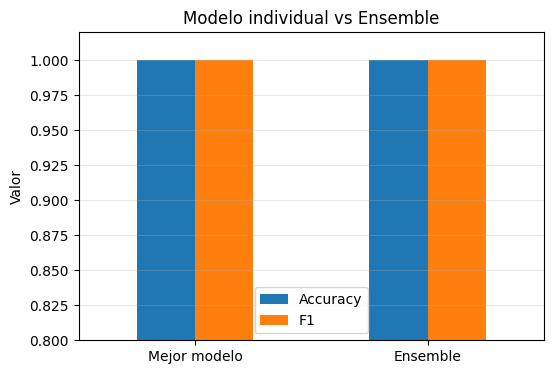

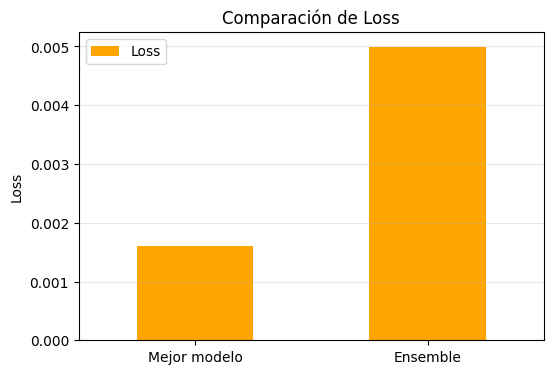

In [54]:
# Gráfico
# Accuracy y F1
comparacion_ensemble[['Accuracy','F1']].plot(
    kind='bar',
    rot=0,
    figsize=(6,4)
)

plt.ylim(0.8,1.02)
plt.title("Modelo individual vs Ensemble")
plt.ylabel("Valor")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Loss
comparacion_ensemble[['Loss']].plot(
    kind='bar',
    rot=0,
    figsize=(6,4),
    color='orange'
)

plt.title("Comparación de Loss")
plt.ylabel("Loss")
plt.grid(axis='y', alpha=0.3)
plt.show()

## 4. Test-Time Augmentation (TTA)

En inferencia, cada imagen se evalúa en cuatro vistas válidas: original,
espejo horizontal y rotaciones de −10° y +10°. Se promedian las
probabilidades, no las clases. Esto se hace individualmente para los cuatro
modelos y también para el ensemble final. No se emplean cambios de color ni
transformaciones excesivas en TTA, porque podrían cambiar la identidad de
la fruta o generar una distribución distinta a la de test.

In [55]:
def vistas_tta(imagen, tamano):
    """Cuatro vistas deterministas de una misma imagen para inferencia."""
    base = TF.resize(imagen, [tamano, tamano], interpolation=transforms.InterpolationMode.BILINEAR)
    return [
        base,
        TF.hflip(base),
        TF.rotate(base, -10, interpolation=transforms.InterpolationMode.BILINEAR,
                  fill=(255, 255, 255)),
        TF.rotate(base, 10, interpolation=transforms.InterpolationMode.BILINEAR,
                  fill=(255, 255, 255)),
    ]

class DatasetMultiTTA(Dataset):
    def __init__(self, directorio, nombres_modelos):
        self.muestras = ImageFolder(str(directorio), loader=cargar_imagen_limpia).samples
        self.nombres_modelos = tuple(nombres_modelos)
        self.normalizar = transforms.Compose([
            transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)
        ])

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, indice):
        ruta, etiqueta = self.muestras[indice]
        imagen = cargar_imagen_limpia(ruta)
        vistas_por_modelo = {}
        for nombre in self.nombres_modelos:
            tamano = ESPECIFICACION_MODELOS[nombre]['tamano']
            vistas_por_modelo[nombre] = torch.stack([
                self.normalizar(vista) for vista in vistas_tta(imagen.copy(), tamano)
            ])
        return vistas_por_modelo, etiqueta

@torch.no_grad()
def probabilidades_tta(modelo, batch_vistas):
    # batch_vistas: [batch, n_vistas, C, H, W]
    b, n, c, h, w = batch_vistas.shape
    logits = modelo(batch_vistas.to(device).reshape(b * n, c, h, w))
    return torch.softmax(logits, dim=1).reshape(b, n, -1).mean(dim=1)

@torch.no_grad()
def evaluar_tta(modelos_cargados, directorio, pesos_ensemble):

    loader = DataLoader(
        DatasetMultiTTA(directorio, modelos_cargados.keys()),
        batch_size=8,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == 'cuda')
    )

    y_true = []
    y_pred_individual = {nombre: [] for nombre in modelos_cargados.keys()}
    y_pred_ensemble = []

    loss_total = 0.0
    total = 0

    for vistas, etiquetas in loader:

        etiquetas_gpu = etiquetas.to(device)

        probs_ensemble = None

        for nombre, modelo in modelos_cargados.items():

            probs = probabilidades_tta(modelo, vistas[nombre])

            y_pred_individual[nombre].extend(
                probs.argmax(dim=1).cpu().numpy()
            )

            aporte = pesos_ensemble[nombre] * probs

            probs_ensemble = (
                aporte if probs_ensemble is None
                else probs_ensemble + aporte
            )

        # Loss del ensemble con TTA
        loss_total += F.nll_loss(
            probs_ensemble.clamp_min(1e-8).log(),
            etiquetas_gpu,
            reduction='sum'
        ).item()

        total += etiquetas.size(0)

        y_true.extend(etiquetas.numpy())
        y_pred_ensemble.extend(
            probs_ensemble.argmax(dim=1).cpu().numpy()
        )

    filas = []

    for nombre in modelos_cargados.keys():

        pred = y_pred_individual[nombre]

        filas.append({
            'modelo': nombre,
            'accuracy_tta': np.mean(np.array(y_true) == np.array(pred)),
            'f1_macro_tta': f1_score(
                y_true,
                pred,
                average='macro'
            ),
        })

    filas.append({
        'modelo': 'ensemble_ponderado',
        'loss_tta': loss_total / total,
        'accuracy_tta': np.mean(
            np.array(y_true) == np.array(y_pred_ensemble)
        ),
        'f1_macro_tta': f1_score(
            y_true,
            y_pred_ensemble,
            average='macro'
        ),
    })

    return (
        pd.DataFrame(filas)
        .set_index('modelo')
        .sort_values('f1_macro_tta', ascending=False)
    )

resultados_tta_val = evaluar_tta(
    MODELOS_ENSEMBLE,
    BASE_DIR_R / 'val',
    PESOS_ENSEMBLE
)

resultados_tta_test = evaluar_tta(
    MODELOS_ENSEMBLE,
    BASE_DIR_R / 'test',
    PESOS_ENSEMBLE
)
print('TTA en validación')
display(resultados_tta_val)
print('TTA en test')
display(resultados_tta_test) 

TTA en validación


,accuracy_tta,f1_macro_tta,loss_tta
modelo,,,
resnet18,1.0,1.0,NaN
efficientnet_b0,1.0,1.0,NaN
vit_b_16,1.0,1.0,NaN
ensemble_ponderado,1.0,1.0,0.004795


TTA en test


,accuracy_tta,f1_macro_tta,loss_tta
modelo,,,
resnet18,1.0,1.0,NaN
efficientnet_b0,1.0,1.0,NaN
vit_b_16,1.0,1.0,NaN
ensemble_ponderado,1.0,1.0,0.005938


In [56]:
RESULTADO_TTA = resultados_tta_val.loc['ensemble_ponderado']

comparacion_tta = pd.DataFrame({
    'Accuracy': [
        RESULTADO_ENSEMBLE['accuracy'],
        RESULTADO_TTA['accuracy_tta']
    ],
    'F1': [
        RESULTADO_ENSEMBLE['f1_macro'],
        RESULTADO_TTA['f1_macro_tta']
    ],
    'Loss': [
        RESULTADO_ENSEMBLE['loss'],
        RESULTADO_TTA['loss_tta']
    ]
},
index=['Sin TTA','Con TTA'])

display(comparacion_tta.round(4))

,Accuracy,F1,Loss
Sin TTA,1.0,1.0,0.0050
Con TTA,1.0,1.0,0.0048


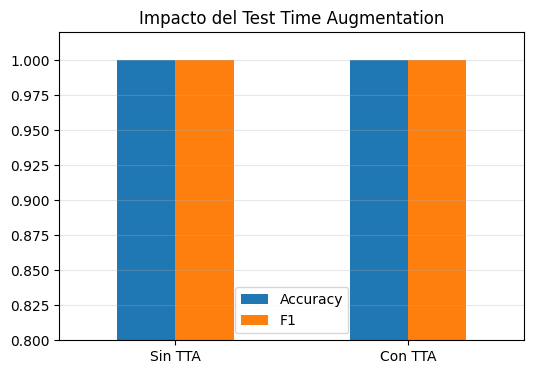

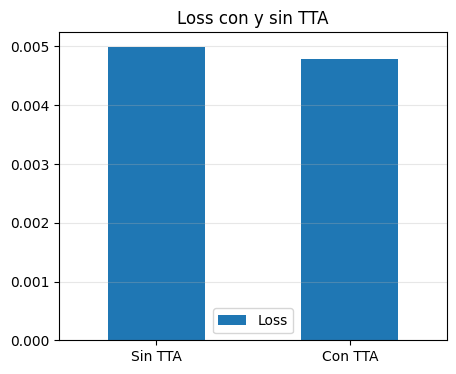

In [57]:
comparacion_tta[['Accuracy','F1']].plot(
    kind='bar',
    figsize=(6,4),
    rot=0
)

plt.ylim(0.8,1.02)
plt.title("Impacto del Test Time Augmentation")
plt.grid(axis='y', alpha=0.3)
plt.show()

comparacion_tta[['Loss']].plot(
    kind='bar',
    figsize=(5,4),
    rot=0
)

plt.title("Loss con y sin TTA")
plt.grid(axis='y', alpha=0.3)
plt.show()

Ahora se aplica TTA al mejor modelo, como el obtenido para la comparación de Ensemble, para ver si hay mejoras significativas.

Mejor modelo seleccionado: vit_b_16


,Accuracy,F1,Loss
vit_b_16 (sin TTA),1.0,1.0,0.0002
vit_b_16 (con TTA),1.0,1.0,0.0002
Ensemble (sin TTA),1.0,1.0,0.0050
Ensemble (con TTA),1.0,1.0,0.0048


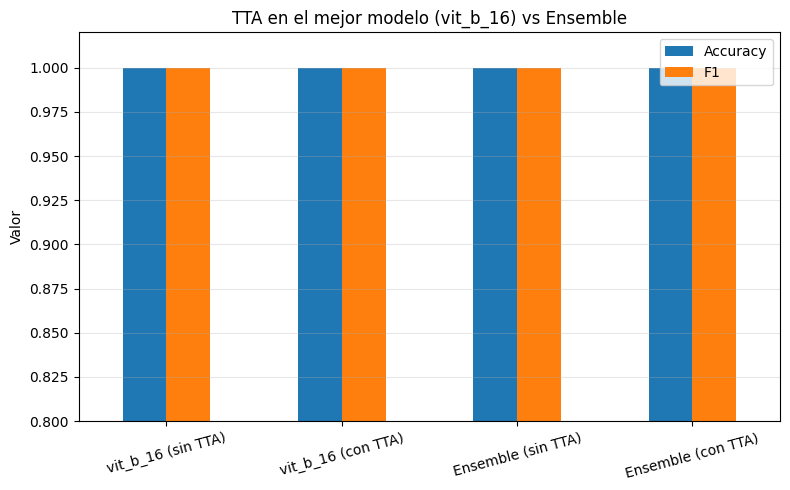

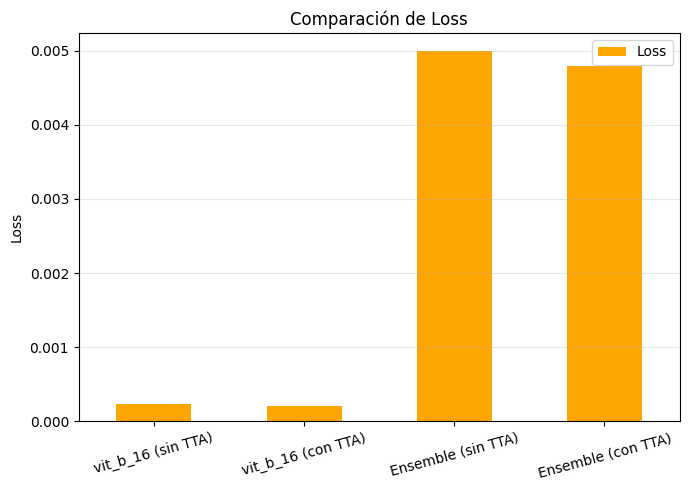

In [61]:
# ============================================================
# TTA aplicado al MEJOR MODELO individual (el mismo tomado en la celda de Ensemble)
# ============================================================

nombre_mejor_modelo = (
    metricas_individuales_val
    .sort_values(
        by=["accuracy", "f1_macro", "loss"],
        ascending=[False, False, True]
    )
    .index[0]
)

modelo_mejor_individual = MODELOS_FINALES[nombre_mejor_modelo]
modelo_mejor_individual.eval()

print(f"Mejor modelo seleccionado: {nombre_mejor_modelo}")

# --- Métricas sin TTA (ya calculadas en la etapa de Ensemble) ---
metricas_sin_tta = metricas_individuales_val.loc[nombre_mejor_modelo]

# --- Aplicar TTA únicamente a este modelo ---
@torch.no_grad()
def evaluar_tta_modelo_unico(modelo, nombre_modelo, directorio):
    loader = DataLoader(
        DatasetMultiTTA(directorio, [nombre_modelo]),
        batch_size=8,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == 'cuda')
    )
    y_true, y_pred, perdida_total, total = [], [], 0.0, 0
    for vistas, etiquetas in loader:
        etiquetas_gpu = etiquetas.to(device)
        probs = probabilidades_tta(modelo, vistas[nombre_modelo])
        perdida_total += F.nll_loss(
            probs.clamp_min(1e-8).log(), etiquetas_gpu, reduction='sum'
        ).item()
        total += etiquetas.size(0)
        y_true.extend(etiquetas.numpy())
        y_pred.extend(probs.argmax(dim=1).cpu().numpy())
    return {
        'loss': perdida_total / total,
        'accuracy': float(np.mean(np.array(y_true) == np.array(y_pred))),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
    }

metricas_con_tta = evaluar_tta_modelo_unico(
    modelo_mejor_individual, nombre_mejor_modelo, BASE_DIR_R / 'val'
)

# --- Cuadro comparativo: mejor modelo y ensemble, con y sin TTA ---
comparacion_mejor_tta = pd.DataFrame({
    'Accuracy': [
        metricas_sin_tta['accuracy'],
        metricas_con_tta['accuracy'],
        RESULTADO_ENSEMBLE['accuracy'],
        RESULTADO_TTA['accuracy_tta'],
    ],
    'F1': [
        metricas_sin_tta['f1_macro'],
        metricas_con_tta['f1_macro'],
        RESULTADO_ENSEMBLE['f1_macro'],
        RESULTADO_TTA['f1_macro_tta'],
    ],
    'Loss': [
        metricas_sin_tta['loss'],
        metricas_con_tta['loss'],
        RESULTADO_ENSEMBLE['loss'],
        RESULTADO_TTA['loss_tta'],
    ],
}, index=[
    f'{nombre_mejor_modelo} (sin TTA)',
    f'{nombre_mejor_modelo} (con TTA)',
    'Ensemble (sin TTA)',
    'Ensemble (con TTA)',
])

display(comparacion_mejor_tta.round(4))

# --- Gráficos ---
comparacion_mejor_tta[['Accuracy', 'F1']].plot(
    kind='bar', figsize=(8, 5), rot=15
)
plt.ylim(0.8, 1.02)
plt.title(f"TTA en el mejor modelo ({nombre_mejor_modelo}) vs Ensemble")
plt.ylabel("Valor")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

comparacion_mejor_tta[['Loss']].plot(
    kind='bar', figsize=(7, 5), rot=15, color='orange'
)
plt.title("Comparación de Loss")
plt.ylabel("Loss")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
# 🏆 Submission para la Competencia Kaggle
## UTN-IA 2026: Fruit & Vegetable Classifier

Ahora que se generaron varios modelos utilizando las diferentes técnicas enumeradas, generamos el archivo `submission.csv` del modelo que mejores estadísticas obtuvo para subirlo a la competencia. Con mejores estadísticas me refiero a Accuracy y F1-Score altos y Loss bajo.

**Competencia:** https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier

**Formato requerido:**
```
image_id,label
img_0001.jpg,apple
img_0002.jpg,tomato
...
```

**Clases válidas:** `apple`, `banana`, `grapes`, `potato`, `tomato`

In [60]:
ETAPAS_CHECKPOINTS = {
    'baseline':     {nombre: ESPECIFICACION_MODELOS[nombre]['checkpoint_base'] for nombre in NOMBRES_MODELOS},
    'augmentation': {nombre: CHECKPOINTS_AGRESIVOS[nombre] for nombre in NOMBRES_MODELOS},
    'finetuning':   {nombre: CHECKPOINTS_FINETUNING[nombre] for nombre in NOMBRES_MODELOS},
}

@torch.no_grad()
def evaluar_checkpoint(nombre, checkpoint):
    modelo = cargar_modelo_experimento(nombre, checkpoint)
    modelo.eval()
    _, val_loader, _ = crear_loaders(nombre, transform_eval(ESPECIFICACION_MODELOS[nombre]['tamano']))
    loss, acc, f1 = evaluar(modelo, val_loader, nn.CrossEntropyLoss(), device)
    return modelo, {'accuracy': acc, 'f1_macro': f1, 'loss': loss}

candidatos = {}
modelos_evaluados = {}

for etapa, checkpoints in ETAPAS_CHECKPOINTS.items():
    for nombre, ckpt in checkpoints.items():
        clave = f'{nombre} ({etapa})'
        modelo_cargado, metricas = evaluar_checkpoint(nombre, ckpt)
        candidatos[clave] = metricas
        modelos_evaluados[clave] = (nombre, modelo_cargado)

# Ensemble ya calculado en la celda correspondiente
candidatos['Ensemble (sin TTA)'] = resultado_ensemble_val
candidatos['Ensemble (con TTA)'] = {
    'accuracy': RESULTADO_TTA['accuracy_tta'],
    'f1_macro': RESULTADO_TTA['f1_macro_tta'],
    'loss':     RESULTADO_TTA['loss_tta'],
}

tabla_candidatos = pd.DataFrame(candidatos).T.sort_values(
    by=['accuracy', 'f1_macro', 'loss'], ascending=[False, False, True]
)
display(tabla_candidatos.round(4))

ganador = tabla_candidatos.index[0]

# --- Si el ganador es un modelo individual, probar si TTA lo mejora aún más ---
normalizar_tta = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)])

@torch.no_grad()
def evaluar_tta_modelo_unico(modelo, nombre_modelo, directorio):
    loader = DataLoader(
        DatasetMultiTTA(directorio, [nombre_modelo]),
        batch_size=8, shuffle=False, num_workers=0,
        pin_memory=(device.type == 'cuda')
    )
    y_true, y_pred, perdida_total, total = [], [], 0.0, 0
    for vistas, etiquetas in loader:
        etiquetas_gpu = etiquetas.to(device)
        probs = probabilidades_tta(modelo, vistas[nombre_modelo])
        perdida_total += F.nll_loss(probs.clamp_min(1e-8).log(), etiquetas_gpu, reduction='sum').item()
        total += etiquetas.size(0)
        y_true.extend(etiquetas.numpy())
        y_pred.extend(probs.argmax(dim=1).cpu().numpy())
    return {
        'loss': perdida_total / total,
        'accuracy': float(np.mean(np.array(y_true) == np.array(y_pred))),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
    }

if ganador not in ('Ensemble (sin TTA)', 'Ensemble (con TTA)'):
    nombre_ganador, modelo_ganador = modelos_evaluados[ganador]
    metricas_tta = evaluar_tta_modelo_unico(modelo_ganador, nombre_ganador, BASE_DIR_R / 'val')
    fila_tta = pd.DataFrame({f'{ganador} + TTA': metricas_tta}).T
    tabla_candidatos = pd.concat([tabla_candidatos, fila_tta]).sort_values(
        by=['accuracy', 'f1_macro', 'loss'], ascending=[False, False, True]
    )

display(tabla_candidatos.round(4))
ganador_final = tabla_candidatos.index[0]
print(f"🏆 Método final elegido para el submission: {ganador_final}")

# --- Predicción sobre las imágenes reales de la competencia ---
DIR_TEST = Path("/kaggle/input/datasets/juancruzmondino/datos-necesarios/test_competencia/utn_competencia_test/test_images")
imagenes_test = sorted([p for p in DIR_TEST.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
print(f"✅ {len(imagenes_test)} imágenes de test listas para predecir")

CLASES_COMP = ["apple", "banana", "grapes", "potato", "tomato"]

@torch.no_grad()
def predecir_individual(modelo, nombre_modelo, imagenes, usar_tta):
    tamano = ESPECIFICACION_MODELOS[nombre_modelo]['tamano']
    etiquetas = []
    for img_path in imagenes:
        imagen = cargar_imagen_limpia(img_path)
        if usar_tta:
            vistas = torch.stack([normalizar_tta(v) for v in vistas_tta(imagen.copy(), tamano)]).unsqueeze(0)
            probs = probabilidades_tta(modelo, vistas)
        else:
            tensor = transform_eval(tamano)(imagen).unsqueeze(0).to(device)
            probs = torch.softmax(modelo(tensor), dim=1)
        etiquetas.append(CLASES_EXP[probs.argmax(dim=1).item()])
    return etiquetas

@torch.no_grad()
def predecir_ensemble(modelos_dict, pesos, imagenes, usar_tta):
    etiquetas = []
    for img_path in imagenes:
        imagen = cargar_imagen_limpia(img_path)
        probs_totales = None
        for nombre, modelo in modelos_dict.items():
            tamano = ESPECIFICACION_MODELOS[nombre]['tamano']
            if usar_tta:
                vistas = torch.stack([normalizar_tta(v) for v in vistas_tta(imagen.copy(), tamano)]).unsqueeze(0)
                probs = probabilidades_tta(modelo, vistas)
            else:
                tensor = transform_eval(tamano)(imagen.copy()).unsqueeze(0).to(device)
                probs = torch.softmax(modelo(tensor), dim=1)
            aporte = pesos[nombre] * probs
            probs_totales = aporte if probs_totales is None else probs_totales + aporte
        etiquetas.append(CLASES_EXP[probs_totales.argmax(dim=1).item()])
    return etiquetas

if ganador_final == 'Ensemble (sin TTA)':
    etiquetas_finales = predecir_ensemble(MODELOS_ENSEMBLE, PESOS_ENSEMBLE, imagenes_test, usar_tta=False)
elif ganador_final == 'Ensemble (con TTA)':
    etiquetas_finales = predecir_ensemble(MODELOS_ENSEMBLE, PESOS_ENSEMBLE, imagenes_test, usar_tta=True)
elif ganador_final.endswith('+ TTA'):
    clave_base = ganador_final.replace(' + TTA', '')
    nombre_m, modelo_m = modelos_evaluados[clave_base]
    etiquetas_finales = predecir_individual(modelo_m, nombre_m, imagenes_test, usar_tta=True)
else:
    nombre_m, modelo_m = modelos_evaluados[ganador_final]
    etiquetas_finales = predecir_individual(modelo_m, nombre_m, imagenes_test, usar_tta=False)

df_sub = pd.DataFrame({
    'image_id': [p.stem for p in imagenes_test],
    'label': etiquetas_finales
})

clases_invalidas = df_sub[~df_sub['label'].isin(CLASES_COMP)]
if len(clases_invalidas) > 0:
    print(f"⚠️ {len(clases_invalidas)} predicciones con clases inválidas:")
    print(clases_invalidas)
else:
    print(f"✅ Todas las {len(df_sub)} predicciones tienen clases válidas")

print(df_sub['label'].value_counts())

df_sub.to_csv("/kaggle/working/submission.csv", index=False)
print(f"📄 submission.csv guardado usando: {ganador_final}")

,accuracy,f1_macro,loss
vit_b_16 (finetuning),1.0000,1.0000,0.0002
resnet18 (finetuning),1.0000,1.0000,0.0016
Ensemble (sin TTA),1.0000,1.0000,0.0035
Ensemble (con TTA),1.0000,1.0000,0.0048
efficientnet_b0 (finetuning),1.0000,1.0000,0.0086
vit_b_16 (augmentation),1.0000,1.0000,0.0116
vit_b_16 (baseline),1.0000,1.0000,0.0528
efficientnet_b0 (augmentation),1.0000,1.0000,0.0819
resnet18 (augmentation),1.0000,1.0000,0.0839
efficientnet_b0 (baseline),0.9783,0.9751,0.0995


,accuracy,f1_macro,loss
vit_b_16 (finetuning) + TTA,1.0000,1.0000,0.0002
vit_b_16 (finetuning),1.0000,1.0000,0.0002
resnet18 (finetuning),1.0000,1.0000,0.0016
Ensemble (sin TTA),1.0000,1.0000,0.0035
Ensemble (con TTA),1.0000,1.0000,0.0048
efficientnet_b0 (finetuning),1.0000,1.0000,0.0086
vit_b_16 (augmentation),1.0000,1.0000,0.0116
vit_b_16 (baseline),1.0000,1.0000,0.0528
efficientnet_b0 (augmentation),1.0000,1.0000,0.0819
resnet18 (augmentation),1.0000,1.0000,0.0839


🏆 Método final elegido para el submission: vit_b_16 (finetuning) + TTA
✅ 89 imágenes de test listas para predecir
✅ Todas las 89 predicciones tienen clases válidas
label
grapes    21
tomato    21
banana    16
potato    16
apple     15
Name: count, dtype: int64
📄 submission.csv guardado usando: vit_b_16 (finetuning) + TTA


---
## Conclusiones

1. **El dataset importa tanto como la arquitectura** — UTN-IA 2026 · Estudio Visual - Etapa 1 (aprox 95%) vs. dataset realista (aprox 75%) con el mismo modelo.
2. **Data Augmentation = regularización** — no solo aumenta datos, enseña robustez al modelo.
3. **Las métricas deben complementarse** — accuracy + F1 + matriz de confusión dan una imagen completa.

## 🎯 Trabajo Práctico: subir el puntaje en la competencia

Con el notebook de clase tenés un baseline. Para el TP, explorá:

- **Transfer Learning** — ResNet18, EfficientNet, ViT preentrenados en ImageNet
- **Data Augmentation agresivo** — MixUp, CutMix, RandAugment
- **Fine-tuning** — descongelar capas del backbone gradualmente
- **Ensemble** — promediar predicciones de varios modelos
- **Test-Time Augmentation (TTA)** — predecir con múltiples crops/flips y promediar

**Métrica:** F1 Score Weighted — penaliza clases minoritarias mal predichas.

**URL competencia:** https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier